In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# First I read in the data
indeed_w1 = pd.read_csv("./new_data/Indeed_w1.csv", sep=",", skiprows=1)
indeed_w2 = pd.read_csv("./new_data/Indeed_w2.csv", sep=",", skiprows=1)
indeed_w3 = pd.read_csv("./new_data/Indeed_w3.csv", sep=",", skiprows=1)

stepstone_w1 = pd.read_csv("./new_data/Stepstone_w1.csv", sep=",", skiprows=1)
stepstone_w2 = pd.read_csv("./new_data/Stepstone_w2.csv", sep=",", skiprows=1)
stepstone_w3 = pd.read_csv("./new_data/Stepstone_w3.csv", sep=",", skiprows=1)

Bewerbung_w1 = pd.read_csv("./new_data/Bewerbung_w1.csv", sep=",", skiprows=1)
Bewerbung_w2 = pd.read_csv("./new_data/Bewerbung_w2.csv", sep=",", skiprows=1)
Bewerbung_w3 = pd.read_csv("./new_data/Bewerbung_w3.csv", sep=",", skiprows=1)

arbeitsamt_w1 = pd.read_csv("./new_data/Arbeitsamt_w1.csv", sep=",", skiprows=1)
arbeitsamt_w2 = pd.read_csv("./new_data/Arbeitsamt_w2.csv", sep=",", skiprows=1)
arbeitsamt_w3 = pd.read_csv("./new_data/Arbeitsamt_w3.csv", sep=",", skiprows=1)

jobbörse_w1 = pd.read_csv("./new_data/Jobbörse_w1.csv", sep=",", skiprows=1)
jobbörse_w2 = pd.read_csv("./new_data/Jobbörse_w2.csv", sep=",", skiprows=1)
jobbörse_w3 = pd.read_csv("./new_data/Jobbörse_w3.csv", sep=",", skiprows=1)

# Define the columns
indeed_w1.columns = ["Date", "indeed"]
indeed_w2.columns = ["Date", "indeed"]
indeed_w3.columns = ["Date", "indeed"]

stepstone_w1.columns = ["Date", "stepstone"]
stepstone_w2.columns = ["Date", "stepstone"]
stepstone_w3.columns = ["Date", "stepstone"]

Bewerbung_w1.columns = ["Date","bewerbung"]
Bewerbung_w2.columns = ["Date","bewerbung"]
Bewerbung_w3.columns = ["Date","bewerbung"]

arbeitsamt_w1.columns = ["Date", "arbeitsamt"]
arbeitsamt_w2.columns = ["Date", "arbeitsamt"]
arbeitsamt_w3.columns = ["Date", "arbeitsamt"]

jobbörse_w1.columns = ["Date", "jobbörse"]
jobbörse_w2.columns = ["Date", "jobbörse"]
jobbörse_w3.columns = ["Date", "jobbörse"]








In [3]:
# make them date
for df in [indeed_w1,indeed_w2,indeed_w3, stepstone_w1, stepstone_w2, stepstone_w3, Bewerbung_w1,Bewerbung_w2,Bewerbung_w3, arbeitsamt_w1,arbeitsamt_w2,arbeitsamt_w3, jobbörse_w1, jobbörse_w2, jobbörse_w3]:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    # convert value column to numercic (some lines may have non-numeric stuff)
    df[df.columns[1]] = pd.to_numeric(df[df.columns[1]], errors="coerce")

In [4]:
import pandas as pd
import numpy as np

# --- Endpoints: weekly vs monthly
START = pd.Timestamp("2011-05-01")      # Sunday
END_WEEK = pd.Timestamp("2023-01-29")   # Sunday
END_MONTH = pd.Timestamp("2023-01-31")  # Month-end label for monthly data

def _prep(df, value_col):
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df.dropna(subset=["Date", value_col]).set_index("Date").sort_index()
    return df

def _median_ratio(a, b):
    idx = a.index.intersection(b.index)
    x, y = a.loc[idx], b.loc[idx]
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() == 0:
        return 1.0
    return np.median((x[mask] / y[mask]).values)

def stitch_three(w1, w2, w3, value_col, final_name=None):
    W1 = _prep(w1, value_col)
    W2 = _prep(w2, value_col)
    W3 = _prep(w3, value_col)

    s21 = _median_ratio(W1[value_col], W2[value_col])
    W2r = W2 * s21

    s32 = _median_ratio(W2r[value_col], W3[value_col])
    W3r = W3 * s32

    out = pd.concat([
        W1,
        W2r.loc[~W2r.index.isin(W1.index)],
        W3r.loc[~W3r.index.isin(W1.index.union(W2r.index))]
    ]).sort_index()

    # Trim to weekly analysis window (Sundays)
    out = out.loc[(out.index >= START) & (out.index <= END_WEEK)].copy()

    if final_name is None:
        final_name = value_col
    out.columns = [final_name]
    out = out.reset_index().rename(columns={"index": "Date"})
    return out

# --- Build stitched weekly series
indeed     = stitch_three(indeed_w1,     indeed_w2,     indeed_w3,     "indeed",     "indeed")
stepstone  = stitch_three(stepstone_w1,  stepstone_w2,  stepstone_w3,  "stepstone",  "stepstone")
Bewerbung  = stitch_three(Bewerbung_w1,  Bewerbung_w2,  Bewerbung_w3,  "bewerbung",  "bewerbung")
arbeitsamt = stitch_three(arbeitsamt_w1, arbeitsamt_w2, arbeitsamt_w3, "arbeitsamt", "arbeitsamt")
jobbörse   = stitch_three(jobbörse_w1,   jobbörse_w2,   jobbörse_w3,   "jobbörse",   "jobbörse")

# --- Sanity (weekly Sunday grid)
for name, d in [("indeed", indeed), ("stepstone", stepstone), ("jobbörse", jobbörse), ("arbeitsamt", arbeitsamt), ("Bewerbung", Bewerbung)]:
    assert d["Date"].min() == START and d["Date"].max() == END_WEEK, f"{name} weekly range mismatch"
    assert (d["Date"].diff().dropna().dt.days == 7).all(), f"{name} not weekly by 7-day steps"

# --- Merge (weekly aligned)
df_week = (stepstone.merge(indeed,     on="Date", how="inner")
                   .merge(jobbörse,   on="Date", how="inner")
                   .merge(arbeitsamt, on="Date", how="inner")
                   .merge(Bewerbung,  on="Date", how="inner"))

# Optional: save weekly
# df_week.to_csv("./new_data/google_weekly_stitched_merged.csv", index=False)

# --- If you want MONTHLY (to align with unemployment at month-end labels)
df_month = (df_week.set_index("Date")
                    .resample("M").mean()
                    .reset_index())
# Ensure last label is 2023-01-31
assert df_month["Date"].max() == END_MONTH, "Monthly last date not 2023-01-31"

# Optional: save monthly
# df_month.to_csv("./new_data/google_monthly_stitched_merged.csv", index=False)


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_47433/3039807760.py:73: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M").mean()


In [5]:
# ==========================================================
#  BIWEEKLY AGGREGATION  (Zimmer-style W12 / W34prev design)
# ==========================================================
import pandas as pd

# df_week: weekly merged Google Trends (columns like ['stepstone','indeed','jobbörse','arbeitsamt','bewerbung'])
# Date column: weekly Sundays
wk = df_week.copy()
wk["Date"] = pd.to_datetime(wk["Date"])
wk = wk.set_index("Date").sort_index()

# --- Helper calendar columns
wk["year"]  = wk.index.year
wk["month"] = wk.index.month
wk["day"]   = wk.index.day

# --- W12(M): weeks from days 1–15 within month M (early-month activity)
w12 = (
    wk[wk["day"] <= 15]
    .groupby(pd.Grouper(freq="M"))[
        ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
    ].mean()
)
w12.columns = [c + "_W12" for c in w12.columns]

# --- W34(M−1): weeks from days >15 of month M−1 (late-month activity)
# Shift forward by one month to align them with month M
w34_prev = (
    wk[wk["day"] > 15]
    .groupby(pd.Grouper(freq="M"))[
        ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
    ].mean()
)
w34_prev = w34_prev.shift(1, freq="M")
w34_prev.columns = [c + "_W34prev" for c in w34_prev.columns]

# --- Combine W12 and W34prev into a biweekly feature panel aligned to month M
biweekly = pd.concat([w12, w34_prev], axis=1).sort_index()

# --- Trim to your analytical window (month-end timestamps)
biweekly = biweekly.loc["2011-05-31":"2023-01-31"]

print("✅ Biweekly feature panel created:")
print(biweekly.head())
print(biweekly.tail())
print("Shape:", biweekly.shape)


✅ Biweekly feature panel created:
            stepstone_W12  indeed_W12  jobbörse_W12  arbeitsamt_W12  \
Date                                                                  
2011-05-31      50.333333        14.0     78.333333       85.666667   
2011-06-30      49.500000        14.5     79.500000       76.500000   
2011-07-31      52.000000        16.5     88.500000       85.500000   
2011-08-31      54.000000        15.5     93.500000       79.500000   
2011-09-30      52.500000        16.5     95.000000       79.000000   

            bewerbung_W12  stepstone_W34prev  indeed_W34prev  \
Date                                                           
2011-05-31           68.0                NaN             NaN   
2011-06-30           69.5          47.000000       14.000000   
2011-07-31           86.5          51.500000       15.000000   
2011-08-31           73.0          52.333333       15.666667   
2011-09-30           73.5          54.000000       15.500000   

            jobbörs

/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_47433/356134121.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))[
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_47433/356134121.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))[
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_47433/356134121.py:34: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  w34_prev = w34_prev.shift(1, freq="M")


In [6]:
# unemployment 
data = pd.read_csv("unemployment_rate_germany_DE_only.csv", sep=',')
data_copy = data.copy()
data = data[(data["Date"]>= "2011-05-01") & (data["Date"] <= "2023-01-01")]
unemp = data 

unemp.columns = ["Date", "Unemp"]
unemp["Date"] = pd.to_datetime(unemp["Date"])
unemp = unemp.set_index("Date")
# align to month-end index
unemp.index = unemp.index.to_period("M").to_timestamp("M")
panel = biweekly.join(unemp, how="inner")
panel = panel.dropna()


# Stationary test 


stepstone_W12 — lengths
level  raw n = 140
Δ1     raw n = 139
Δ12    raw n = 128


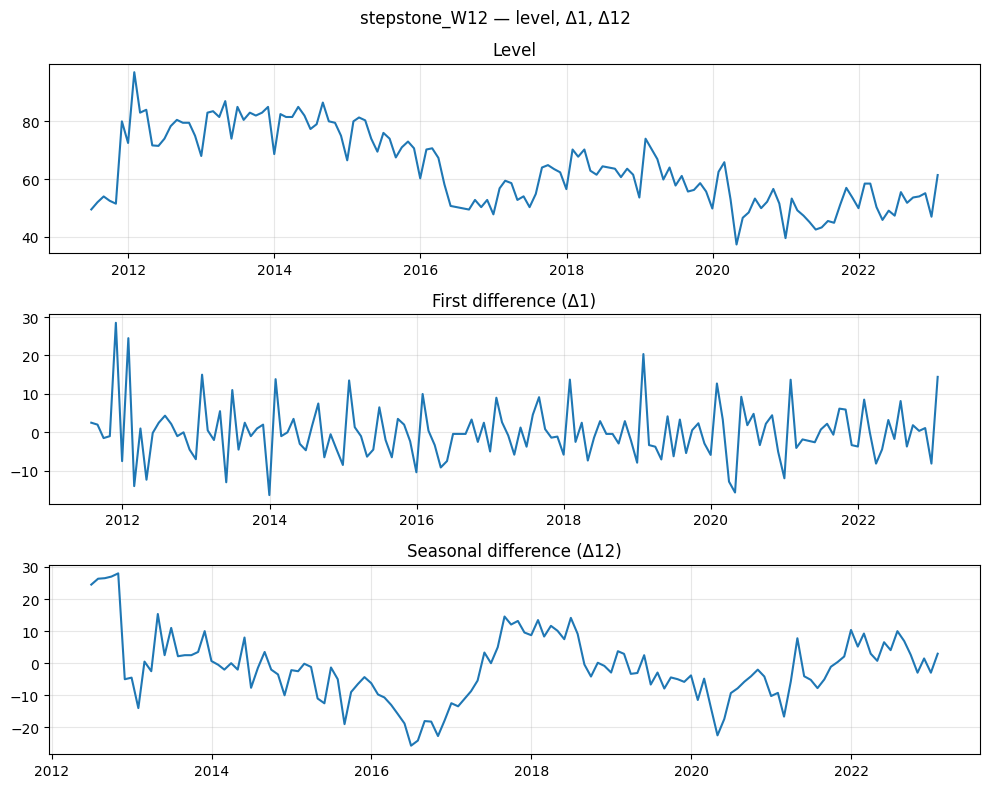

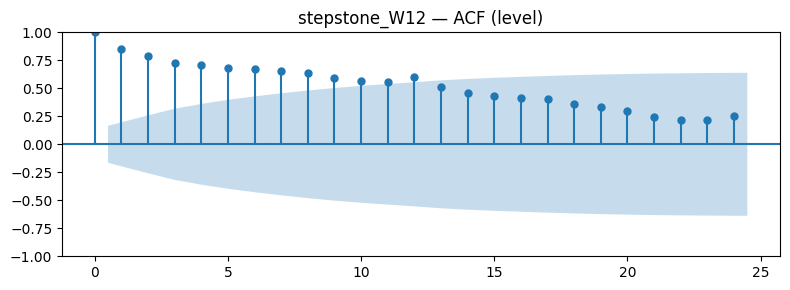

       series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
stepstone_W12     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
stepstone_W12     level   c   -1.6889  0.4368   13.0000  126.0000       140    -3.4833    -2.8848     -2.5792        False        False         False
stepstone_W12     level  ct   -2.5111  0.3224   13.0000  126.0000       140    -4.0325    -3.4459     -3.1478        False        False         False
stepstone_W12     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
stepstone_W12     diff1   c   -3.2986  0.0149   11.0000  127.0000       139    -3.4829    -2.8846     -2.5791        False         True          True
stepstone_W12     diff1  ct   -3.2441  0.0760   11.0000  127.0000       139    -4.0319    -3.4456   

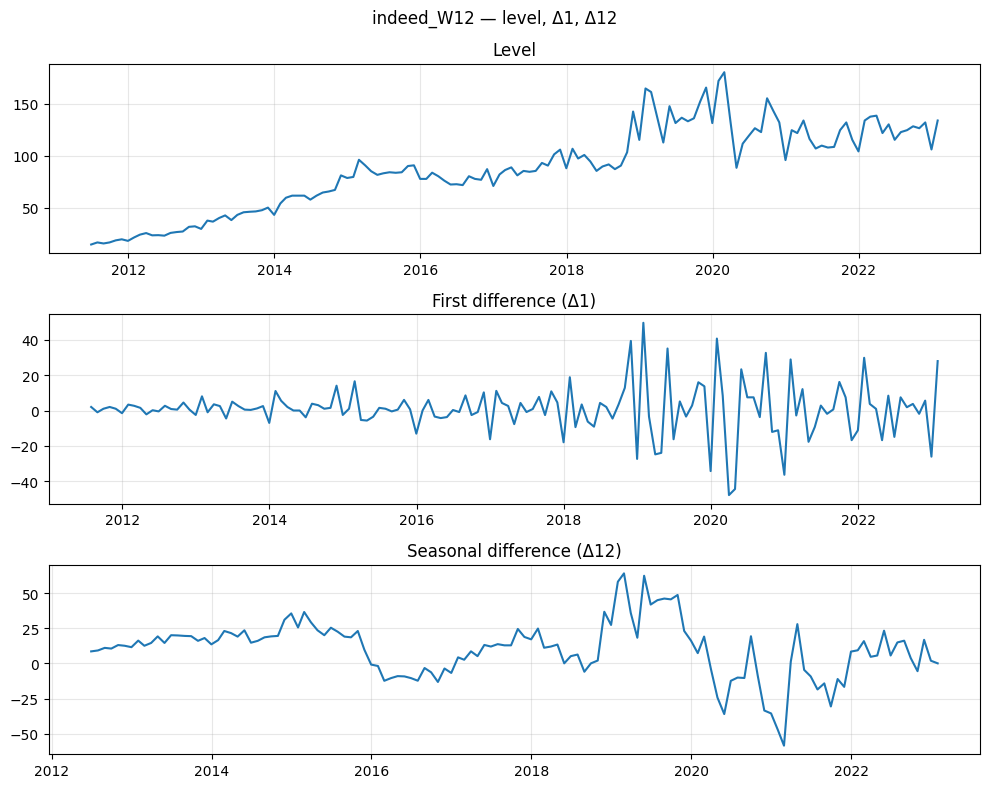

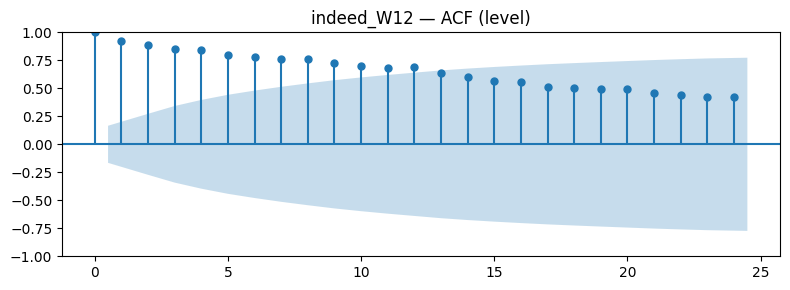

    series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
indeed_W12     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
indeed_W12     level   c   -1.7090  0.4265   13.0000  126.0000       140    -3.4833    -2.8848     -2.5792        False        False         False
indeed_W12     level  ct   -2.5843  0.2872   14.0000  125.0000       140    -4.0331    -3.4462     -3.1480        False        False         False
indeed_W12     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
indeed_W12     diff1   c   -3.4112  0.0106   11.0000  127.0000       139    -3.4829    -2.8846     -2.5791        False         True          True
indeed_W12     diff1  ct   -3.5863  0.0310   11.0000  127.0000       139    -4.0319    -3.4456     -3.1477        Fals

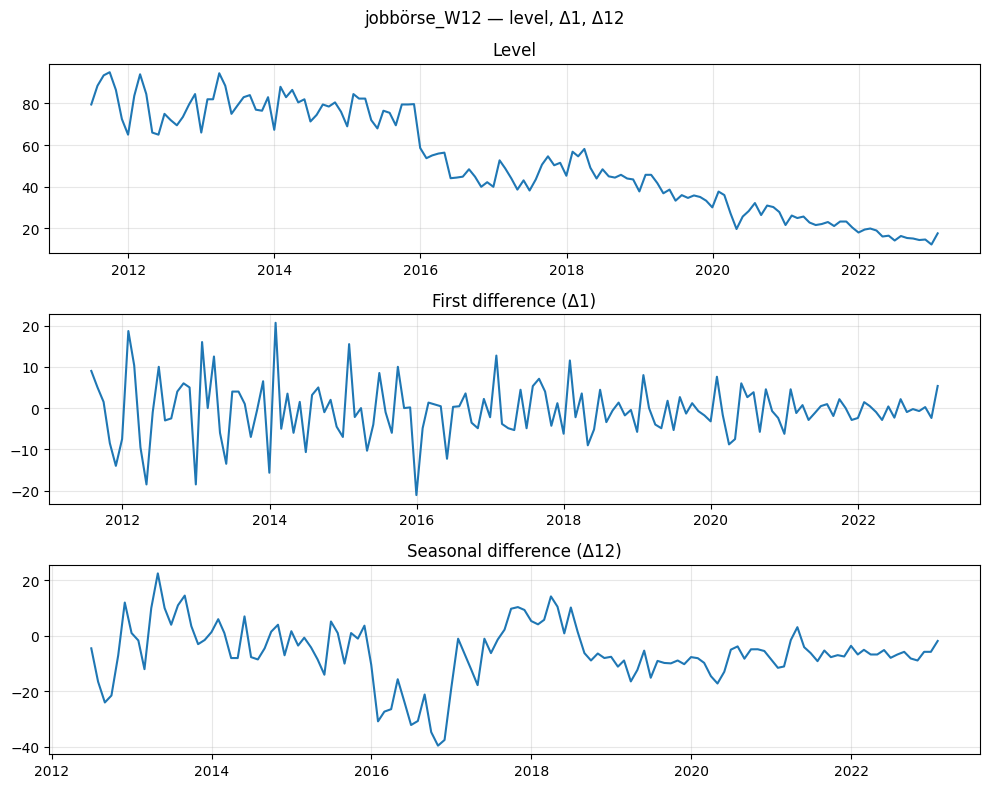

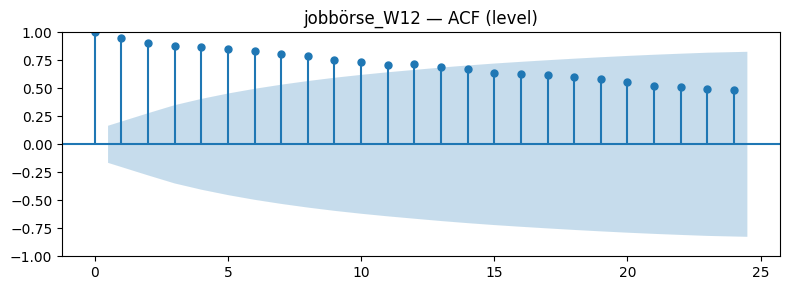

      series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
jobbörse_W12     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
jobbörse_W12     level   c   -0.2388  0.9337   12.0000  127.0000       140    -3.4829    -2.8846     -2.5791        False        False         False
jobbörse_W12     level  ct   -4.1464  0.0054   14.0000  125.0000       140    -4.0331    -3.4462     -3.1480         True         True          True
jobbörse_W12     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
jobbörse_W12     diff1   c   -3.4973  0.0081   11.0000  127.0000       139    -3.4829    -2.8846     -2.5791         True         True          True
jobbörse_W12     diff1  ct   -3.5209  0.0372   11.0000  127.0000       139    -4.0319    -3.4456     -3.14

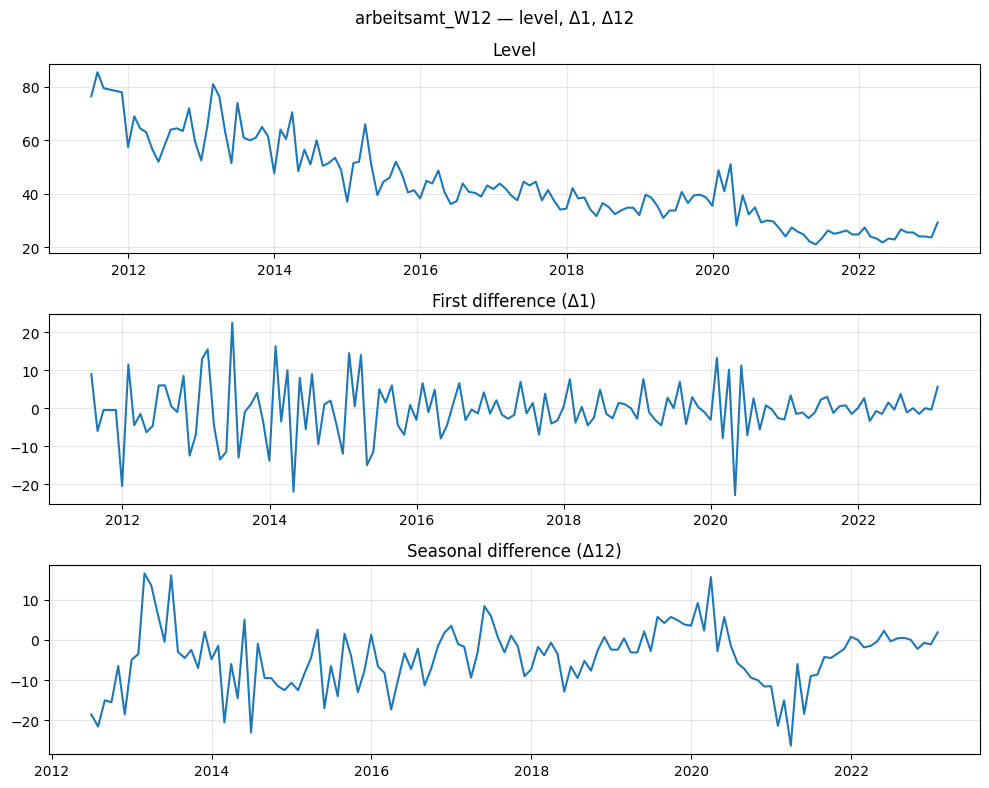

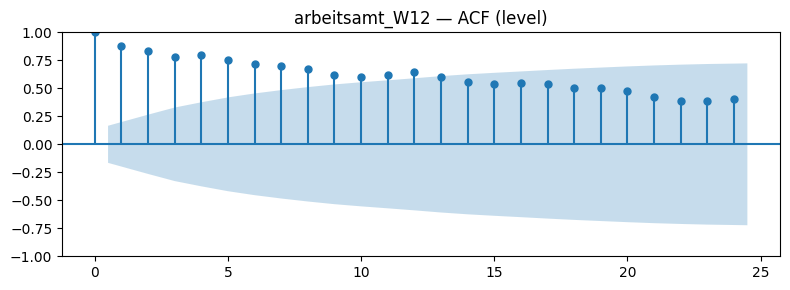

        series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
arbeitsamt_W12     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
arbeitsamt_W12     level   c   -0.8870  0.7922   11.0000  128.0000       140    -3.4825    -2.8844     -2.5790        False        False         False
arbeitsamt_W12     level  ct   -1.7611  0.7232   11.0000  128.0000       140    -4.0313    -3.4454     -3.1475        False        False         False
arbeitsamt_W12     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
arbeitsamt_W12     diff1   c   -6.0830  0.0000   10.0000  128.0000       139    -3.4825    -2.8844     -2.5790         True         True          True
arbeitsamt_W12     diff1  ct   -6.0501  0.0000   10.0000  128.0000       139    -4.0313    -3.

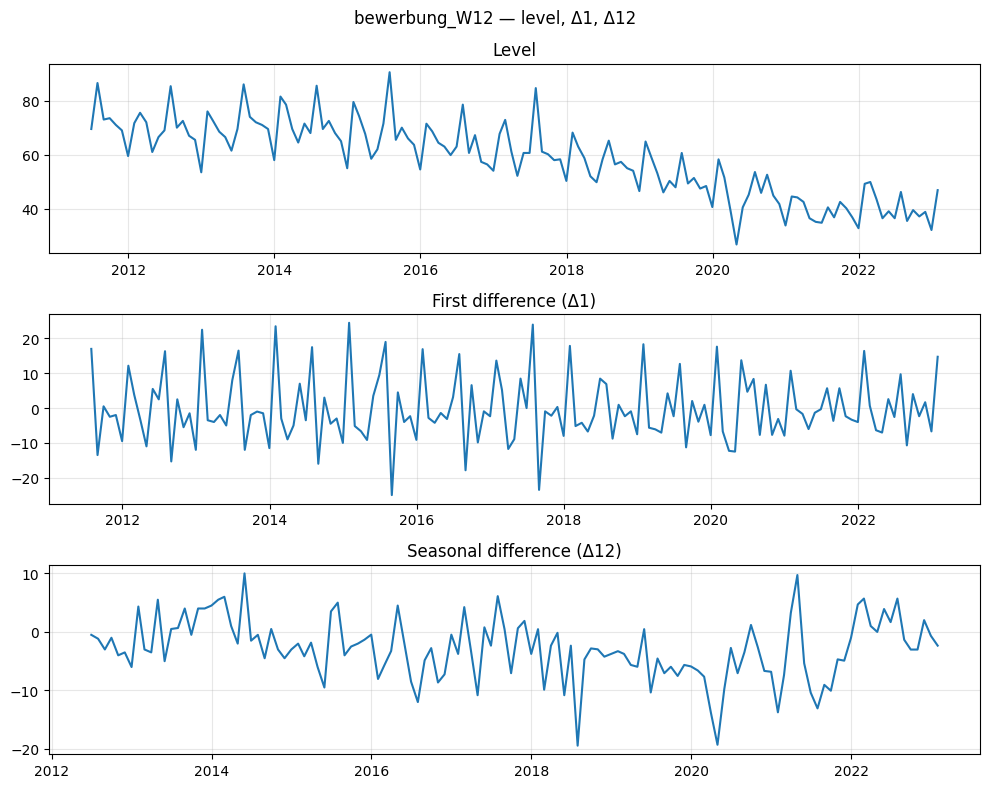

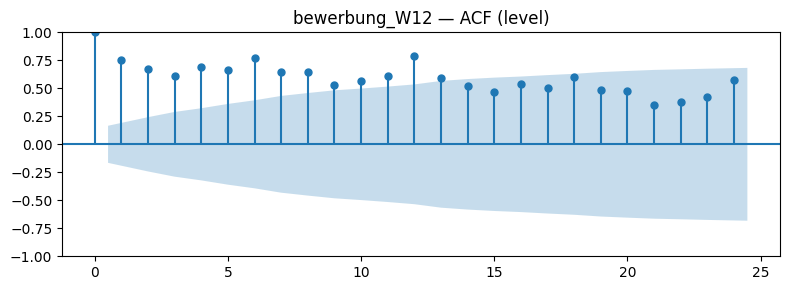

       series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
bewerbung_W12     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
bewerbung_W12     level   c    0.6631  0.9891   12.0000  127.0000       140    -3.4829    -2.8846     -2.5791        False        False         False
bewerbung_W12     level  ct   -2.0718  0.5619   12.0000  127.0000       140    -4.0319    -3.4456     -3.1477        False        False         False
bewerbung_W12     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
bewerbung_W12     diff1   c   -5.5274  0.0000   11.0000  127.0000       139    -3.4829    -2.8846     -2.5791         True         True          True
bewerbung_W12     diff1  ct   -5.7034  0.0000   11.0000  127.0000       139    -4.0319    -3.4456   

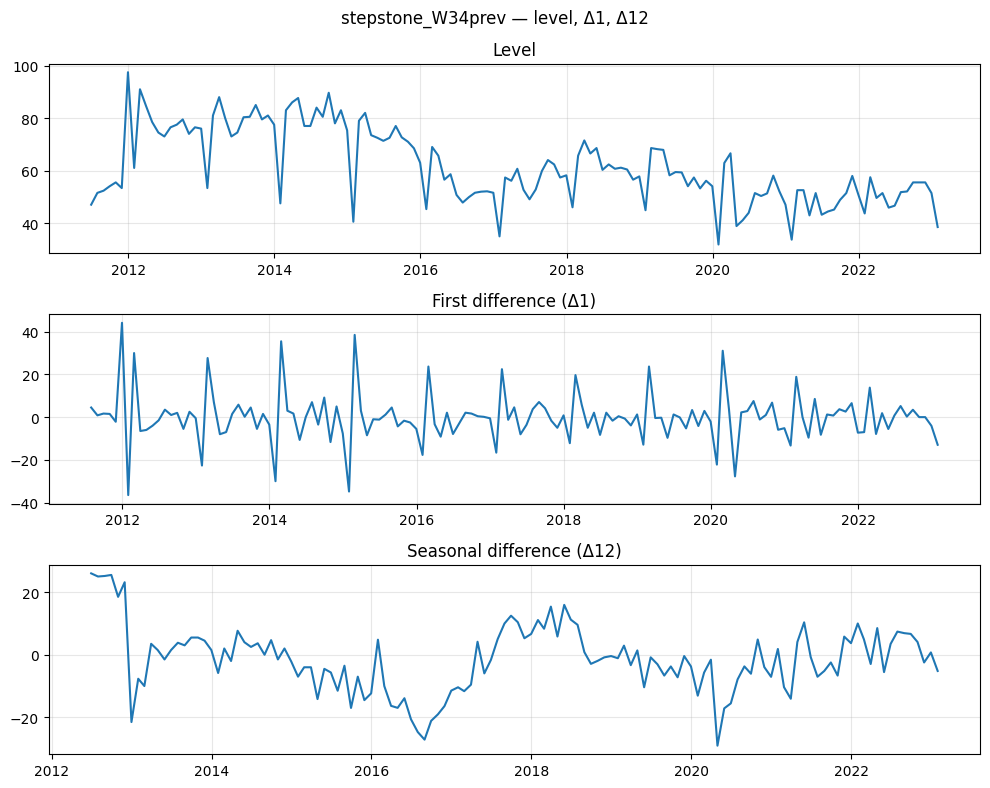

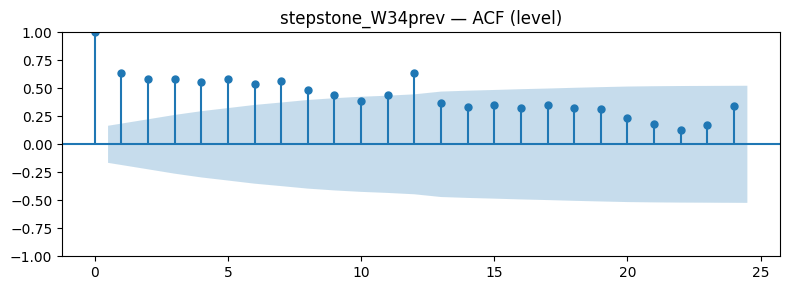

           series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
stepstone_W34prev     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
stepstone_W34prev     level   c   -1.4172  0.5740   13.0000  126.0000       140    -3.4833    -2.8848     -2.5792        False        False         False
stepstone_W34prev     level  ct   -2.4308  0.3634   13.0000  126.0000       140    -4.0325    -3.4459     -3.1478        False        False         False
stepstone_W34prev     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
stepstone_W34prev     diff1   c   -4.1487  0.0008   11.0000  127.0000       139    -3.4829    -2.8846     -2.5791         True         True          True
stepstone_W34prev     diff1  ct   -4.1088  0.0061   11.0000  127.0000       

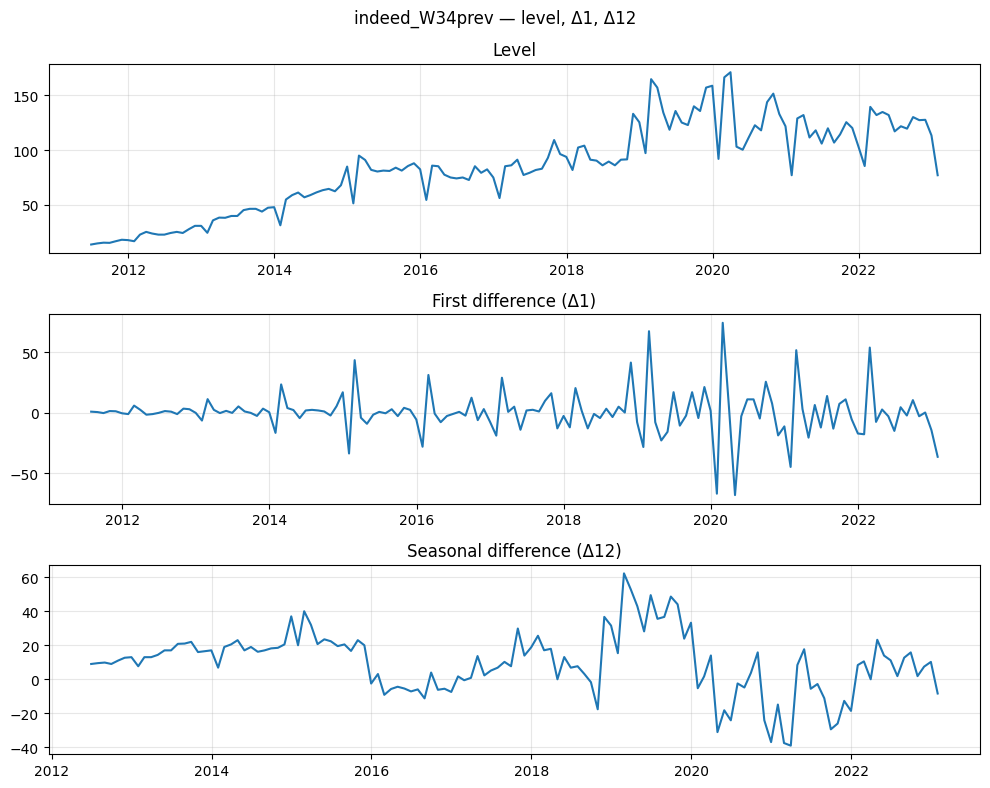

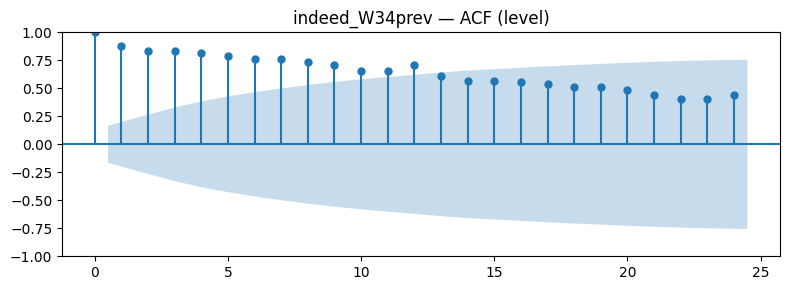

        series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
indeed_W34prev     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
indeed_W34prev     level   c   -1.8303  0.3655   13.0000  126.0000       140    -3.4833    -2.8848     -2.5792        False        False         False
indeed_W34prev     level  ct   -2.4562  0.3502   14.0000  125.0000       140    -4.0331    -3.4462     -3.1480        False        False         False
indeed_W34prev     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
indeed_W34prev     diff1   c   -2.8126  0.0565   14.0000  124.0000       139    -3.4842    -2.8851     -2.5794        False        False          True
indeed_W34prev     diff1  ct   -3.1291  0.0995   14.0000  124.0000       139    -4.0337    -3.

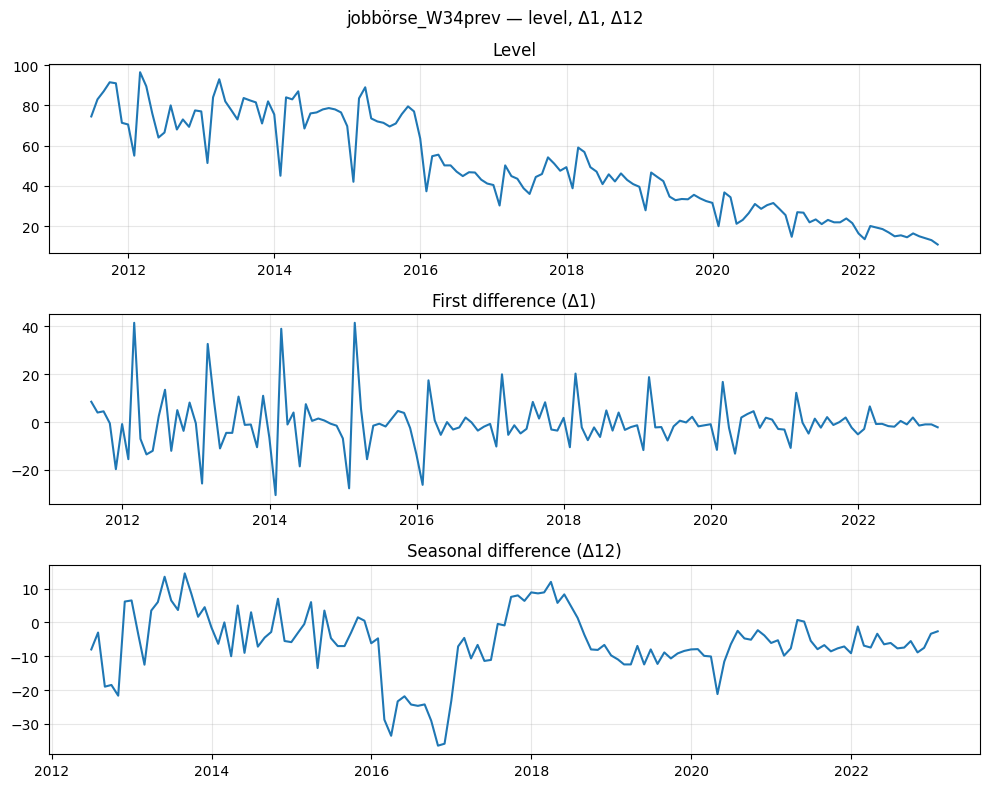

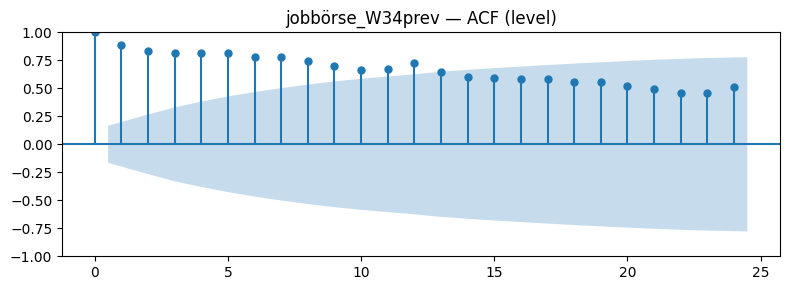

          series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
jobbörse_W34prev     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
jobbörse_W34prev     level   c   -0.1995  0.9386   12.0000  127.0000       140    -3.4829    -2.8846     -2.5791        False        False         False
jobbörse_W34prev     level  ct   -3.0425  0.1206   12.0000  127.0000       140    -4.0319    -3.4456     -3.1477        False        False         False
jobbörse_W34prev     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
jobbörse_W34prev     diff1   c   -3.5185  0.0075   11.0000  127.0000       139    -3.4829    -2.8846     -2.5791         True         True          True
jobbörse_W34prev     diff1  ct   -3.5403  0.0353   11.0000  127.0000       139    

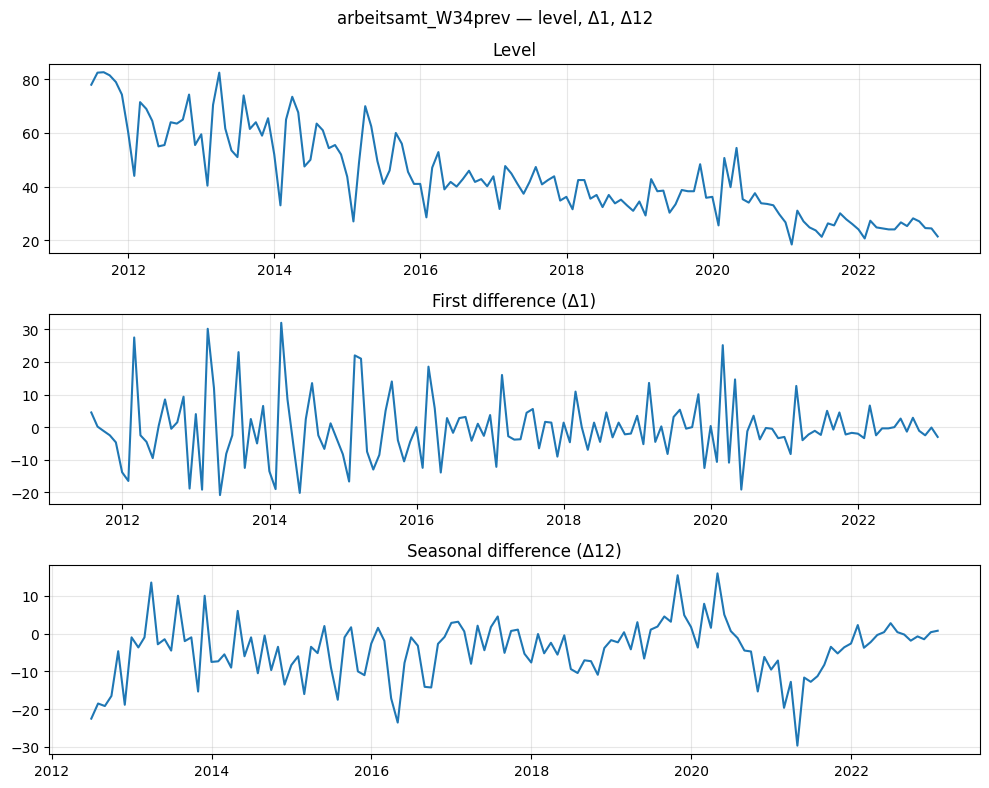

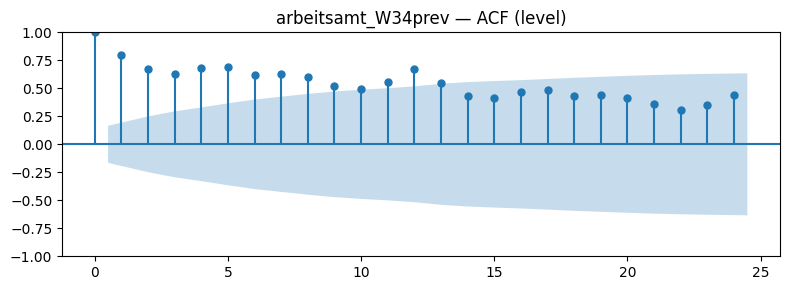

            series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
arbeitsamt_W34prev     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
arbeitsamt_W34prev     level   c   -0.8583  0.8014   13.0000  126.0000       140    -3.4833    -2.8848     -2.5792        False        False         False
arbeitsamt_W34prev     level  ct   -2.3105  0.4282   13.0000  126.0000       140    -4.0325    -3.4459     -3.1478        False        False         False
arbeitsamt_W34prev     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
arbeitsamt_W34prev     diff1   c   -4.2226  0.0006   12.0000  126.0000       139    -3.4833    -2.8848     -2.5792         True         True          True
arbeitsamt_W34prev     diff1  ct   -4.2062  0.0044   12.0000  126.0000

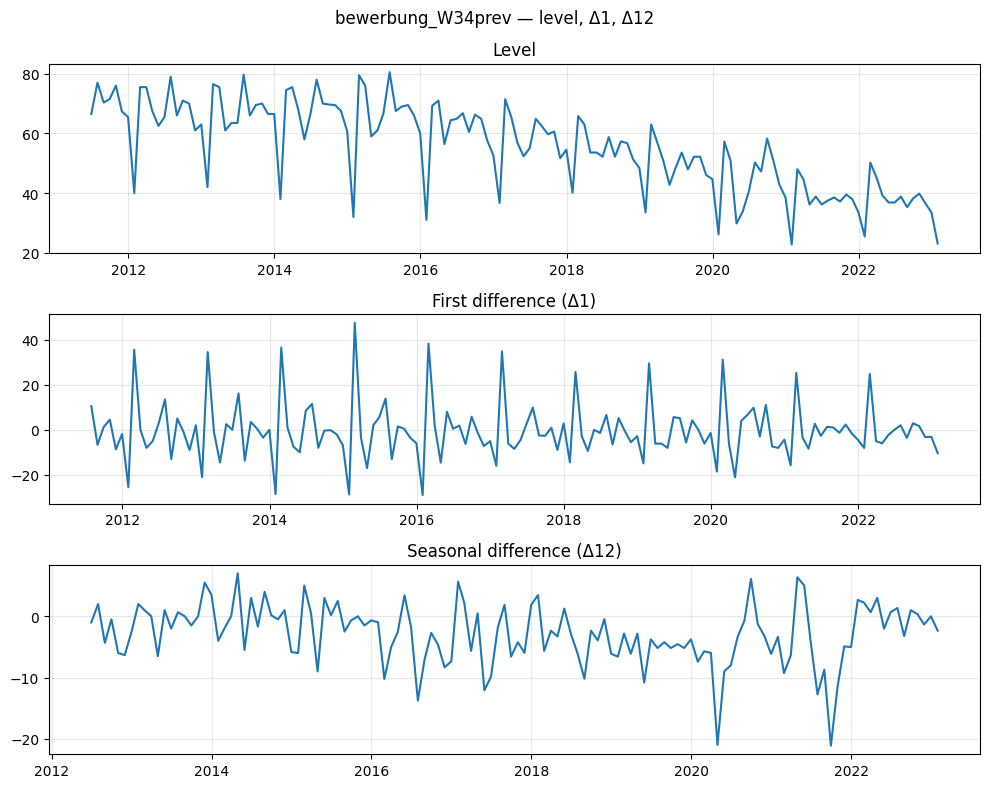

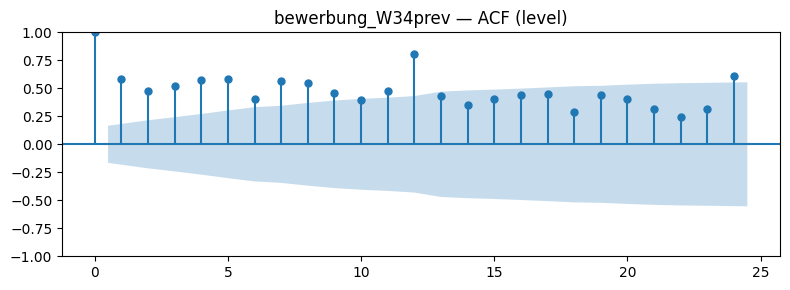

           series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
bewerbung_W34prev     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
bewerbung_W34prev     level   c    1.0137  0.9944   12.0000  127.0000       140    -3.4829    -2.8846     -2.5791        False        False         False
bewerbung_W34prev     level  ct   -1.9437  0.6317   12.0000  127.0000       140    -4.0319    -3.4456     -3.1477        False        False         False
bewerbung_W34prev     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
bewerbung_W34prev     diff1   c   -6.4150  0.0000   11.0000  127.0000       139    -3.4829    -2.8846     -2.5791         True         True          True
bewerbung_W34prev     diff1  ct   -6.6548  0.0000   11.0000  127.0000       

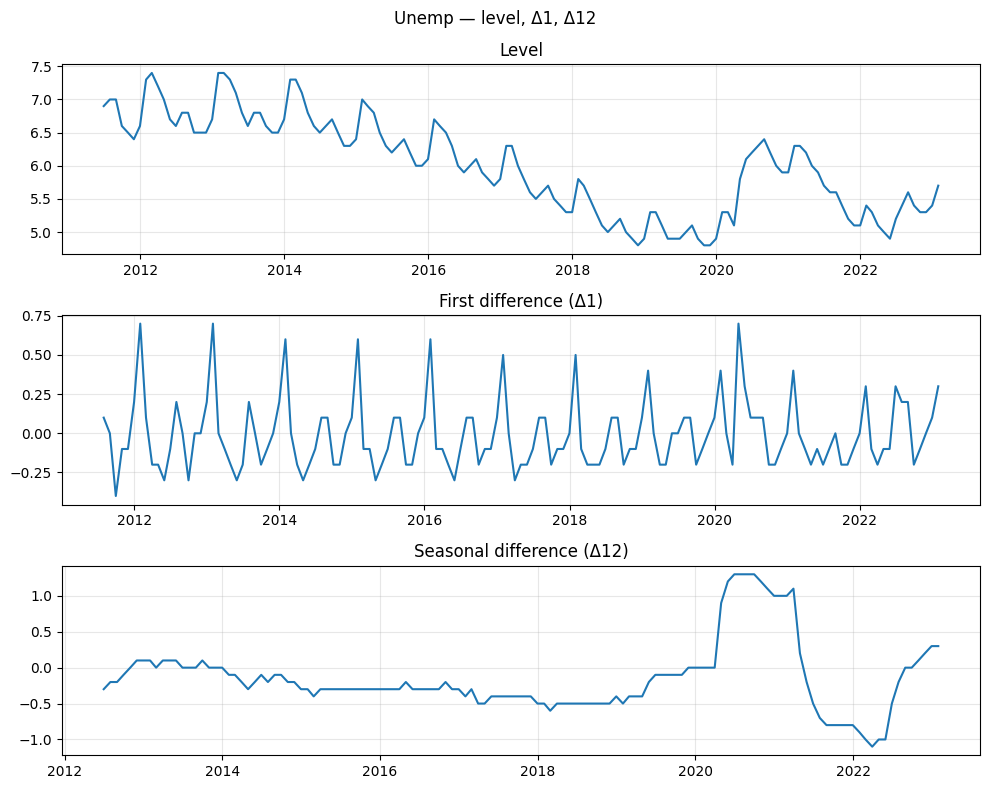

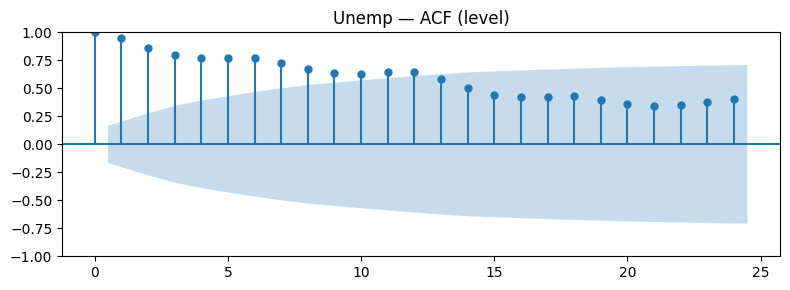

series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
 Unemp     level  nc       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
 Unemp     level   c   -1.4677  0.5494   14.0000  125.0000       140    -3.4838    -2.8850     -2.5793        False        False         False
 Unemp     level  ct   -2.2009  0.4893   14.0000  125.0000       140    -4.0331    -3.4462     -3.1480        False        False         False
 Unemp     diff1  nc       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
 Unemp     diff1   c   -2.8798  0.0478   13.0000  125.0000       139    -3.4838    -2.8850     -2.5793        False        False          True
 Unemp     diff1  ct   -2.8828  0.1682   13.0000  125.0000       139    -4.0331    -3.4462     -3.1480        False        False         False

In [7]:
# =========================
# Complete ADF test battery
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# ----------------- Config -----------------
PLOT_SERIES = True      # set False to skip line plots
PLOT_ACF = True         # set False to skip ACF
ACF_MAXLAG = 24
MIN_LEN = 20            # minimum raw length to even attempt an ADF
MAXLAG = None           # None -> autolag="AIC"; else set an int (e.g., 12)
OUT_CSV = "adf_summary.csv"

# If your working DataFrame is 'panel_ecm', switch this:
# panel = panel_ecm

# ----------------- Helpers -----------------
def infer_seasonal_period(index) -> int | None:
    """
    Infer a sensible seasonal period m from a DatetimeIndex frequency.
    Returns 12 for monthly, 4 for quarterly, 7 for daily (weekly seasonality),
    52 for weekly, 365 for daily (yearly) if frequency suggests it; else None.
    """
    if not isinstance(index, pd.DatetimeIndex):
        return None

    # Use pandas' frequency inference if available
    freq = pd.infer_freq(index)
    if freq is None:
        # fallback: try heuristic by average steps
        diffs = pd.Series(index[1:] - index[:-1]).dt.days.dropna()
        if diffs.empty:
            return None
        step = int(round(diffs.median()))
        if step == 1:   # daily data
            return 7    # weekly seasonality as a pragmatic default
        return None

    f = freq.upper()

    # common cases
    if f.startswith("M"):   # month end/begin
        return 12
    if f.startswith("Q"):   # quarter end/begin
        return 4
    if f.startswith("W"):   # weekly
        return 52
    if f in ("D", "B"):     # daily or business daily
        return 7            # default to weekly cycle for daily data
    if f.startswith("H"):
        return 24
    return None

def adf_all(y: pd.Series,
            name: str,
            maxlag: int | None = None,
            min_len: int = 20,
            seasonal_period: int | None = None) -> pd.DataFrame:
    """
    Run ADF under regressions: 'nc', 'c', 'ct' on
    - level
    - first difference (Δ1)
    - seasonal difference (Δm) if m provided
    Returns a tidy DataFrame with stats, pvalues, used lag, obs counts, and critical values.
    """
    y = pd.Series(y, copy=False)
    cols = [
        "series","transform","reg",
        "adf_stat","pvalue",
        "used_lag","nobs_eff","nobs_raw",
        "crit_1pct","crit_5pct","crit_10pct",
        "reject_1pct","reject_5pct","reject_10pct"
    ]
    out = []

    def run_one(series, transform_label):
        series = pd.Series(series).dropna()
        nraw = int(series.shape[0])
        if nraw < min_len:
            for reg in ("nc","c","ct"):
                out.append((name, transform_label, reg,
                            np.nan, np.nan,
                            np.nan, np.nan, nraw,
                            np.nan, np.nan, np.nan,
                            False, False, False))
            return

        for reg in ("nc","c","ct"):
            try:
                stat, p, usedlag, nobs, crit, icbest = adfuller(
                    series,
                    regression=reg,
                    autolag="AIC" if maxlag is None else None,
                    maxlag=maxlag
                )
                c1, c5, c10 = crit.get("1%"), crit.get("5%"), crit.get("10%")
                # ADF rejects if stat is MORE NEGATIVE than critical value
                r1 = bool((stat is not None) and (c1 is not None) and (stat < c1))
                r5 = bool((stat is not None) and (c5 is not None) and (stat < c5))
                r10 = bool((stat is not None) and (c10 is not None) and (stat < c10))
                out.append((name, transform_label, reg,
                            stat, p,
                            usedlag, nobs, nraw,
                            c1, c5, c10,
                            r1, r5, r10))
            except Exception:
                out.append((name, transform_label, reg,
                            np.nan, np.nan,
                            np.nan, np.nan, nraw,
                            np.nan, np.nan, np.nan,
                            False, False, False))

    # Level
    run_one(y, "level")
    # Δ1
    run_one(y.diff(), "diff1")
    # Δm (seasonal difference) if applicable
    if seasonal_period and seasonal_period >= 2:
        run_one(y.diff(seasonal_period), f"diff{seasonal_period}")

    return pd.DataFrame(out, columns=cols)

# ----------------- Main: per-column analysis -----------------
all_results = []
for col in panel.columns:
    s = pd.to_numeric(panel[col], errors="coerce")
    s_level = s.dropna()
    m = infer_seasonal_period(s.index)

    print("\n" + "="*80)
    print(f"{col} — lengths")
    print(f"level  raw n = {s_level.shape[0]}")
    print(f"Δ1     raw n = {s.diff().dropna().shape[0]}")
    if m:
        print(f"Δ{m:<5} raw n = {s.diff(m).dropna().shape[0]}")

    # Optional plots
    if PLOT_SERIES:
        fig, axes = plt.subplots(3 if m else 2, 1, figsize=(10, 8 if m else 6), sharex=False)
        fig.suptitle(f"{col} — level, Δ1" + (f", Δ{m}" if m else ""), y=0.98)
        # level
        if not s_level.empty:
            axes[0].plot(s_level.index, s_level.values)
        axes[0].set_title("Level")
        axes[0].grid(True, alpha=0.3)
        # Δ1
        d1 = s.diff().dropna()
        if not d1.empty:
            axes[1].plot(d1.index, d1.values)
        axes[1].set_title("First difference (Δ1)")
        axes[1].grid(True, alpha=0.3)
        # Δm
        if m:
            dm = s.diff(m).dropna()
            if not dm.empty:
                axes[2].plot(dm.index, dm.values)
            axes[2].set_title(f"Seasonal difference (Δ{m})")
            axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    if PLOT_ACF:
        vals = s_level
        if len(vals) > ACF_MAXLAG:
            fig2, ax2 = plt.subplots(figsize=(8, 3))
            plot_acf(vals, ax=ax2, lags=ACF_MAXLAG)
            ax2.set_title(f"{col} — ACF (level)")
            plt.tight_layout()
            plt.show()

    # Run ADFs
    res = adf_all(
        s,
        name=col,
        maxlag=MAXLAG,
        min_len=MIN_LEN,
        seasonal_period=m
    )

    # Nice compact display for this series
    display_cols = [
        "series","transform","reg",
        "adf_stat","pvalue","used_lag","nobs_eff","nobs_raw",
        "crit_1pct","crit_5pct","crit_10pct",
        "reject_1pct","reject_5pct","reject_10pct"
    ]
    with pd.option_context("display.float_format", "{:,.4f}".format):
        print(res[display_cols].to_string(index=False))

    all_results.append(res)

# ----------------- Portfolio summary & export -----------------
adf_summary = pd.concat(all_results, ignore_index=True)

# convenience flags at 5%
adf_summary["reject_5pct_flag"] = adf_summary["reject_5pct"].astype(bool)

# What is stationary at level under ANY deterministic spec?
stationary_level_any = (
    adf_summary.query("transform=='level'")
               .groupby("series")["reject_5pct_flag"].any()
               .reset_index(name="reject_at_level_any_spec_5pct")
)

# Robust (ALL specs reject at 5%) — stricter
stationary_level_all = (
    adf_summary.query("transform=='level'")
               .groupby("series")["reject_5pct_flag"].all()
               .reset_index(name="reject_at_level_all_specs_5pct")
)

print("\n" + "-"*80)
print("Stationary at LEVEL (p<0.05) under ANY spec:")
print(stationary_level_any.to_string(index=False))
print("\nStationary at LEVEL (p<0.05) under ALL specs (strict):")
print(stationary_level_all.to_string(index=False))

# Best spec per transform by smallest p-value (for reporting)
best_by_p = (
    adf_summary
    .dropna(subset=["pvalue"])
    .sort_values(["series","transform","pvalue"], ascending=[True, True, True])
    .groupby(["series","transform"], as_index=False)
    .first()[["series","transform","reg","adf_stat","pvalue","used_lag","nobs_eff"]]
    .rename(columns={"reg":"best_reg_by_min_p"})
)
print("\nBest ADF (min p-value) per series x transform:")
with pd.option_context("display.float_format", "{:,.4f}".format):
    print(best_by_p.to_string(index=False))

# Save full tidy table
adf_summary.to_csv(OUT_CSV, index=False)
print(f"\nSaved full results to: {OUT_CSV}")


# Conclusion
- Jobbörse w12 is stationary in levels
- indeed prev is not stationary in first differences

In [8]:
# Augmeted dickey fuller test for the zero mean reverting case
from statsmodels.tsa.stattools import adfuller

adf_diff_nc = []
for col in panel.columns:
    s = pd.to_numeric(panel[col], errors="coerce").dropna()
    d1 = s.diff().dropna()
    if len(d1) < 20:
        continue
    stat, p, usedlag, nobs, crit, icbest = adfuller(d1, regression="n", autolag="AIC")
    adf_diff_nc.append({"series": col, "ADF Δ1 (nc)": stat, "pvalue": p, "lag": usedlag})

adf_diff_nc = pd.DataFrame(adf_diff_nc)
print(adf_diff_nc.round(4))


                series  ADF Δ1 (nc)  pvalue  lag
0        stepstone_W12      -3.2242  0.0013   11
1           indeed_W12      -2.4965  0.0121   12
2         jobbörse_W12      -3.0608  0.0022   11
3       arbeitsamt_W12      -5.5334  0.0000   10
4        bewerbung_W12      -3.4875  0.0005   12
5    stepstone_W34prev      -4.0136  0.0001   11
6       indeed_W34prev      -2.4891  0.0124   14
7     jobbörse_W34prev      -2.9936  0.0027   11
8   arbeitsamt_W34prev      -3.6222  0.0003   12
9    bewerbung_W34prev      -5.1217  0.0000   11
10               Unemp      -2.8170  0.0047   13


All are stationary considering this case

# Pre Johansen cointegration check

In [11]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import warnings

warnings.filterwarnings("ignore")

def cointegration_prereq_check(df, signif=0.05):
    print("=== Johansen Prerequisite Diagnostic ===\n")

    results = []

    # --- Step 1: Check I(1) using ADF test on level
    print("Step 1: Testing stationarity (ADF in levels)...")
    for col in df.columns:
        series = df[col].dropna().astype(float)
        adf_stat, p_val, *_ = adfuller(series, autolag='AIC')
        result = "I(1) candidate" if p_val > signif else "Stationary (I(0))"
        print(f"  {col:25s}  ADF stat={adf_stat:8.3f}, p={p_val:6.4f}  →  {result}")
        results.append((col, p_val))

    print("\nStep 2: Testing first differences for I(0)...")
    for col in df.columns:
        series = df[col].dropna().astype(float).diff().dropna()
        adf_stat, p_val, *_ = adfuller(series, autolag='AIC')
        result = "✅ stationary in Δ (I(1) confirmed)" if p_val < signif else "⚠️ not stationary in Δ (possible I(2))"
        print(f"  Δ{col:24s}  ADF stat={adf_stat:8.3f}, p={p_val:6.4f}  →  {result}")

    # --- Step 3: Check multicollinearity
    print("\nStep 3: Checking multicollinearity (pairwise correlation > 0.95 flagged)...")
    corr = df.corr()
    flagged = []
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            c = corr.iloc[i, j]
            if abs(c) > 0.95:
                flagged.append((corr.columns[i], corr.columns[j], c))
    if flagged:
        for (v1, v2, c) in flagged:
            print(f"  ⚠️ High correlation: {v1} ↔ {v2}  ({c:.3f})")
    else:
        print("  ✅ No severe multicollinearity detected.")

    # --- Step 4: Check time index frequency and alignment
    print("\nStep 4: Checking index alignment...")
    if isinstance(df.index, pd.DatetimeIndex):
        freq = pd.infer_freq(df.index)
        if freq is None:
            print("  ⚠️ No consistent frequency detected (may have missing or irregular dates).")
        else:
            print(f"  ✅ Time index frequency appears consistent: {freq}")
    else:
        print("  ⚠️ Index is not a DatetimeIndex — Johansen requires time-ordered data.")

    print("\n=== Summary ===")
    print("✔ Proceed to Johansen test if: variables are I(1), not I(2), low multicollinearity, and index aligned.\n")

# Example call
cointegration_prereq_check(panel[['Unemp','stepstone_W12','stepstone_W34prev','arbeitsamt_W12','arbeitsamt_W34prev','bewerbung_W12','bewerbung_W34prev']])


=== Johansen Prerequisite Diagnostic ===

Step 1: Testing stationarity (ADF in levels)...
  Unemp                      ADF stat=  -1.468, p=0.5494  →  I(1) candidate
  stepstone_W12              ADF stat=  -1.689, p=0.4368  →  I(1) candidate
  stepstone_W34prev          ADF stat=  -1.417, p=0.5740  →  I(1) candidate
  arbeitsamt_W12             ADF stat=  -0.887, p=0.7922  →  I(1) candidate
  arbeitsamt_W34prev         ADF stat=  -0.858, p=0.8014  →  I(1) candidate
  bewerbung_W12              ADF stat=   0.663, p=0.9891  →  I(1) candidate
  bewerbung_W34prev          ADF stat=   1.014, p=0.9944  →  I(1) candidate

Step 2: Testing first differences for I(0)...
  ΔUnemp                     ADF stat=  -2.880, p=0.0478  →  ✅ stationary in Δ (I(1) confirmed)
  Δstepstone_W12             ADF stat=  -3.299, p=0.0149  →  ✅ stationary in Δ (I(1) confirmed)
  Δstepstone_W34prev         ADF stat=  -4.149, p=0.0008  →  ✅ stationary in Δ (I(1) confirmed)
  Δarbeitsamt_W12            ADF stat=  -6.

# Trying the Johansen test

In [16]:
# ===========================
# Johansen + VECM: triple run
# ===========================
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

# ---------------------------
# 0) Utility: tidy printing
# ---------------------------
def line(msg=""):
    print("-" * (len(msg) if msg else 60))
    if msg:
        print(msg)
        print("-" * (len(msg)))

# --------------------------------------------------
# 1) Choose VAR order p by AIC, then k_ar_diff = p-1
# --------------------------------------------------
def choose_k_ar_diff(level_df: pd.DataFrame, pmax: int = 8) -> int:
    """
    Pick the VAR(p) order in levels by AIC, then set k_ar_diff = p - 1 for Johansen/VECM.
    Caps at [1, pmax]. Falls back to p=2 if AIC not available.
    """
    model = VAR(level_df.dropna())
    sel = model.select_order(maxlags=pmax)
    p = int(sel.aic) if sel.aic is not None else 2
    p = max(1, min(p, pmax))
    return max(1, p - 1)

# ----------------------------------------------------------
# 2) Map Hamilton "cases" to statsmodels deterministics
# ----------------------------------------------------------
# Hamilton Case 1 (no const)   -> det_order=-1 (rare in macro)
# Hamilton Case 2 (const in β) -> det_order=0  (default recommended)
# Hamilton Case 3 (const free) -> det_order=1  (drift)
DET_MAP_VECM = { -1: "nc", 0: "ci", 1: "co", 2: "li", 3: "lo" }

# ----------------------------------------------------------
# 3) Run Johansen, print rank, β; then fit VECM to get α
# ----------------------------------------------------------
def johansen_and_vecm(level_df: pd.DataFrame,
                      det_order: int = 0,
                      pmax: int = 8,
                      alpha_sig: float = 0.05,
                      title: str = ""):
    """
    level_df : DataFrame in LEVELS with columns in desired order (e.g. ['Unemp','X_W12','X_W34prev'])
    det_order: Hamilton Case mapping (0 = restricted constant in cointegration)
    pmax     : max VAR order to consider when choosing k_ar_diff
    """
    names = list(level_df.columns)

    # 1) choose lag length
    kdiff = choose_k_ar_diff(level_df, pmax=pmax)

    # small-sample guard: make sure we have enough rows for estimation
    T = len(level_df.dropna())
    # crude minimum: need at least ~ (kdiff + 5) usable obs
    if T <= kdiff + 5:
        kdiff = max(1, min(2, T - 3))

    # 2) Johansen test
    jres = coint_johansen(level_df.dropna().astype(float),
                          det_order=det_order,
                          k_ar_diff=kdiff)

    # Rank decisions
    trace_stats, trace_cv = jres.lr1, jres.cvt   # cvt cols: [90%, 95%, 99%]
    maxeig_stats, maxeig_cv = jres.lr2, jres.cvm
    r_trace = int(np.sum(trace_stats > trace_cv[:, 1]))   # 95% column
    r_max   = int(np.sum(maxeig_stats > maxeig_cv[:, 1]))

    line(f"Johansen (Case {det_order+2 if det_order>=0 else 1}; det_order={det_order}, k_ar_diff={kdiff}) {title}")
    print("Variables:", names)
    print("Trace stats:   ", np.round(trace_stats, 3), " | 95% crit:", np.round(trace_cv[:, 1], 3))
    print("Max-eig stats: ", np.round(maxeig_stats, 3), " | 95% crit:", np.round(maxeig_cv[:, 1], 3))
    print(f"→ Rank (trace):   r = {r_trace}")
    print(f"→ Rank (max-eig): r = {r_max}")

    # 3) β from Johansen (evec). Normalize each β so coeff on Unemp == 1 for readability.
    beta_j = pd.DataFrame(jres.evec, index=names, columns=[f"β{j+1}" for j in range(jres.evec.shape[1])])
    if "Unemp" in names:
        beta_j = beta_j.div(beta_j.loc["Unemp"], axis=1)
    print("\nβ (Johansen, normalized on Unemp=1):")
    print(beta_j.iloc[:, :max(r_trace, 1)].round(4))

    # 4) Fit VECM with chosen rank (use the trace decision by convention)
    r = max(1, r_trace)  # must be >=1 to identify α; if r_trace=0 you shouldn't fit a VECM.
    det = DET_MAP_VECM.get(det_order, "ci")
    vecm = VECM(level_df.dropna().astype(float),
                k_ar_diff=kdiff,
                coint_rank=r,
                deterministic=det).fit()

    beta = pd.DataFrame(vecm.beta, index=names, columns=[f"β{j+1}" for j in range(vecm.beta.shape[1])])
    alpha = pd.DataFrame(vecm.alpha, index=names, columns=[f"α→EC{j+1}" for j in range(vecm.alpha.shape[1])])
    if "Unemp" in names:
        beta = beta.div(beta.loc["Unemp"], axis=1)

    print(f"\n[VECM fitted] deterministics='{det}', rank={r}, k_ar_diff={kdiff}")
    print("β (VECM, normalized on Unemp=1):")
    print(beta.round(4).iloc[:, :r])
    print("\nα (loading / speed of adjustment):")
    print(alpha.round(4).iloc[:, :r])

    return {
        "rank_trace": r_trace,
        "rank_maxeig": r_max,
        "k_ar_diff": kdiff,
        "deterministic": det,
        "beta_johansen": beta_j.iloc[:, :max(r_trace,1)],
        "beta_vecm": beta.iloc[:, :r],
        "alpha_vecm": alpha.iloc[:, :r],
        "vecm_result": vecm
    }

# ----------------------------------------------------------
# 4) Convenience runner for your three systems
#     (Unemp + W12 + W34prev): Stepstone / Arbeitsamt / Bewerbung
# ----------------------------------------------------------
def run_three_systems(panel: pd.DataFrame, det_order: int = 0, pmax: int = 8):
    # Ensure float and aligned
    def run_for(stem):
        cols = ["Unemp", f"{stem}_W12", f"{stem}_W34prev"]
        df = panel[cols].dropna().astype(float)
        return johansen_and_vecm(df, det_order=det_order, pmax=pmax, title=f"for {stem.title()}")

    out_step = run_for("stepstone")
    out_arb  = run_for("arbeitsamt")
    out_bew  = run_for("bewerbung")
    return out_step, out_arb, out_bew

# -----------------------------
# 5) Execute for your dataset
# -----------------------------
# Example call (Case 2 = restricted constant in the cointegrating relation)
results_step, results_arb, results_bew = run_three_systems(panel, det_order=0, pmax=8)


---------------------------------------------------------
Johansen (Case 2; det_order=0, k_ar_diff=7) for Stepstone
---------------------------------------------------------
Variables: ['Unemp', 'stepstone_W12', 'stepstone_W34prev']
Trace stats:    [57.964  6.315  1.996]  | 95% crit: [29.796 15.494  3.842]
Max-eig stats:  [51.649  4.319  1.996]  | 95% crit: [21.131 14.264  3.842]
→ Rank (trace):   r = 1
→ Rank (max-eig): r = 1

β (Johansen, normalized on Unemp=1):
                       β1
Unemp              1.0000
stepstone_W12      0.9253
stepstone_W34prev -0.9997

[VECM fitted] deterministics='ci', rank=1, k_ar_diff=7
β (VECM, normalized on Unemp=1):
                       β1
Unemp              1.0000
stepstone_W12      0.9196
stepstone_W34prev -0.9934

α (loading / speed of adjustment):
                    α→EC1
Unemp             -0.0381
stepstone_W12     -0.9141
stepstone_W34prev  2.1663
----------------------------------------------------------
Johansen (Case 2; det_order=0, k_ar

| System         | Trace rank | Max-Eig rank | Decision                 |
| -------------- | ---------- | ------------ | ------------------------ |
| **Stepstone**  | 1          | 1            | ✅ 1 cointegrating vector |
| **Arbeitsamt** | 1          | 1            | ✅ 1 cointegrating vector |
| **Bewerbung**  | 1          | 1            | ✅ 1 cointegrating vector |


all three systems have rank = 1, meaning each has one long-run equilibrium relationship linking the three variables.
The Johansen part moreo or less tells you. how many cointegrating relations there are but not the short run adjustment strength.


## checking out whether cointegration results work out

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

def ect_series(df_levels: pd.DataFrame, vecm_res) -> pd.Series:
    # 1) Best: use resid_coint if present
    if hasattr(vecm_res, "resid_coint") and vecm_res.resid_coint is not None:
        ect = pd.Series(np.asarray(vecm_res.resid_coint).squeeze(),
                        index=df_levels.index[-len(vecm_res.resid_coint):],
                        name="ECT")
        return ect

    # 2) Otherwise compute beta' y_t and try to add the coint constant if exposed
    beta = vecm_res.beta                         # (n x r)
    y = df_levels.to_numpy()                     # (T x n)
    ect_raw = (y @ beta).squeeze()              # (T,) for r=1
    ect = pd.Series(ect_raw, index=df_levels.index, name="ECT")

    # add constant in cointegration if available; else center
    c = None
    for attr in ["det_coef_coint", "coint_const", "const_coint"]:
        if hasattr(vecm_res, attr):
            c = getattr(vecm_res, attr)
            break
    if c is not None:
        # c can be shape (r,) or scalar when r=1
        c0 = float(np.atleast_1d(c)[0])
        ect = ect + c0
    else:
        ect = ect - ect.mean()   # pragmatic centering

    return ect

def check_ect_stationarity(df_levels: pd.DataFrame, vecm_res, name="System"):
    ect = ect_series(df_levels, vecm_res)

    plt.figure(figsize=(8,4))
    ect.plot(label="Error-Correction Term")
    plt.axhline(0, color="black", lw=0.8)
    plt.title(f"ECT over time – {name}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    res = adfuller(ect.dropna(), autolag="AIC")
    adf_stat, adf_p, crit = res[0], res[1], res[4]
    print(f"ADF stat = {adf_stat:.3f}, p = {adf_p:.4f}")
    print(f"Critical values: {crit}")
    if adf_p < 0.05:
        print("✅ ECT is stationary → cointegration supported.")
    else:
        print("⚠️ ECT may still have a unit root (weaker cointegration).")


# Now we build the error correction models


## First the stepstone error correction model 

In [30]:
# Stepstone ECM
def ecm_ols_from_vecm(df_levels: pd.DataFrame, vecm_res, k_ar_diff: int, add_month_dummies=True):
    cols = list(df_levels.columns)
    yname = "Unemp"
    others = [c for c in cols if c != yname]

    # Build ECT_{t-1}
    ect = ect_series(df_levels, vecm_res).shift(1).rename("ECT_lag")

    # Build first differences and their lags up to k_ar_diff
    df = df_levels.copy().astype(float)
    df["dUnemp"] = df[yname].diff()
    for v in others:
        df[f"d{v}"] = df[v].diff()
        for L in range(1, k_ar_diff+1):
            df[f"d{v}_L{L}"] = df[f"d{v}"].shift(L)
    df["dUnemp_L1"] = df["dUnemp"].shift(1)

    if add_month_dummies and isinstance(df.index, pd.DatetimeIndex):
        df["month"] = df.index.month

    # merge ECT_{t-1}
    df = df.join(ect)

    # drop NA created by lags
    used = df.dropna()

    # Build formula: ΔUnemp ~ ECT_{t-1} + ΔX + lagged ΔX + ΔUnemp_{t-1} + (dummies)
    rhs_terms = ["ECT_lag", "dUnemp_L1"] + \
                [f"d{v}" for v in others] + \
                sum([[f"d{v}_L{L}" for L in range(1, k_ar_diff+1)] for v in others], [])

    formula = "dUnemp ~ " + " + ".join(rhs_terms)
    if add_month_dummies and "month" in used:
        formula += " + C(month)"

    mod = smf.ols(formula, data=used).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
    return mod, used, formula

df_step = panel[['Unemp','stepstone_W12','stepstone_W34prev']].dropna()
mod_step, used_step, frm_step = ecm_ols_from_vecm(df_step,
    results_step['vecm_result'],
    k_ar_diff=results_step['k_ar_diff'],
    add_month_dummies=True)

print(frm_step)
print(mod_step.summary())


dUnemp ~ ECT_lag + dUnemp_L1 + dstepstone_W12 + dstepstone_W34prev + dstepstone_W12_L1 + dstepstone_W12_L2 + dstepstone_W12_L3 + dstepstone_W12_L4 + dstepstone_W12_L5 + dstepstone_W12_L6 + dstepstone_W12_L7 + dstepstone_W34prev_L1 + dstepstone_W34prev_L2 + dstepstone_W34prev_L3 + dstepstone_W34prev_L4 + dstepstone_W34prev_L5 + dstepstone_W34prev_L6 + dstepstone_W34prev_L7 + C(month)
                            OLS Regression Results                            
Dep. Variable:                 dUnemp   R-squared:                       0.799
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     232.7
Date:                Sat, 08 Nov 2025   Prob (F-statistic):           1.55e-80
Time:                        13:13:47   Log-Likelihood:                 121.83
No. Observations:                 132   AIC:                            -183.7
Df Residuals:                     102   BIC:                 

Results for the stepstone:
ECT_lag = 0.0007 (p = 0.92) → no error-correction in the Unemp equation.
Even though Johansen found r=1, unemployment itself is not adjusting back to the long-run Stepstone equilibrium in the short run.
dUnemp_L1 = 0.427 (p < 0.001) → strong persistence in ΔUnemp.
Short-run signals: dstepstone_W12 = −0.0079 (p=0.028) significant; all other Stepstone lags mostly insignificant.
Interpretation: when Stepstone_W12 rises, ΔUnemp falls slightly this month—useful ***useful contemporaneus signal***
Fit/diagnostics: R² ≈ 0.80; DW ≈ 2 (fine); seasonality strong; residuals non-normal (common; HAC SEs already used).

Stepstone is useful short-run info (W12 contemporaneous), but no meaningful speed of adjustment α for unemployment.





## Now for arbeitsamt

In [31]:
df_arb = panel[['Unemp','arbeitsamt_W12','arbeitsamt_W34prev']].dropna()
mod_arb, used_arb, frm_arb = ecm_ols_from_vecm(df_arb,
    results_arb['vecm_result'],
    k_ar_diff=results_arb['k_ar_diff'],
    add_month_dummies=True)

print(frm_arb)
print(mod_arb.summary())


dUnemp ~ ECT_lag + dUnemp_L1 + darbeitsamt_W12 + darbeitsamt_W34prev + darbeitsamt_W12_L1 + darbeitsamt_W12_L2 + darbeitsamt_W12_L3 + darbeitsamt_W12_L4 + darbeitsamt_W12_L5 + darbeitsamt_W12_L6 + darbeitsamt_W34prev_L1 + darbeitsamt_W34prev_L2 + darbeitsamt_W34prev_L3 + darbeitsamt_W34prev_L4 + darbeitsamt_W34prev_L5 + darbeitsamt_W34prev_L6 + C(month)
                            OLS Regression Results                            
Dep. Variable:                 dUnemp   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                     321.4
Date:                Sat, 08 Nov 2025   Prob (F-statistic):           8.39e-89
Time:                        13:14:29   Log-Likelihood:                 119.63
No. Observations:                 133   AIC:                            -183.3
Df Residuals:                     105   BIC:                            -102.3
Df Model:   

Results for Arbeitsamt 
ECT_lag = −0.0146 (p = 0.024) → significant error-correction in the Unemp equation.
Unemployment reduces about 1.5% of disequilibrium per month. A rough half-life ≈ ln(0.5)/ln(1−0.0146) ≈ ~47 months (slow but real).

dUnemp_L1 = 0.448 (p < 0.001) → persistence again.

Short-run signals:
darbeitsamt_W34prev_L1…L3 are negative and significant (L1 p=0.010, L2 p=0.015, L3 p=0.044). more vacancies (Arbeitsamt W34prev) predict declines in ΔUnemp over the next 1–3 months.
Some positive lags on darbeitsamt_W12 (L3 p=0.039) but the W34prev pattern is the clearer driver.

Fit/diagnostics: R² ≈ 0.80; DW ≈ 2; strong seasonality; non-normal residuals (HAC used).

This is the cleanest ECM: it has a significant α (error correction) and predictive lag structure (W34prev L1–L3). If you want a single ECM to nowcast/forecast Unemployment, Arbeitsamt is your best of the three.

## Now for bewerbung

In [33]:
df_bew = panel[['Unemp','bewerbung_W12','bewerbung_W34prev']].dropna()
mod_bew, used_bew, frm_bew = ecm_ols_from_vecm(df_bew,
    results_bew['vecm_result'],
    k_ar_diff=results_bew['k_ar_diff'],
    add_month_dummies=True)

print(frm_bew)
print(mod_bew.summary())


dUnemp ~ ECT_lag + dUnemp_L1 + dbewerbung_W12 + dbewerbung_W34prev + dbewerbung_W12_L1 + dbewerbung_W12_L2 + dbewerbung_W12_L3 + dbewerbung_W12_L4 + dbewerbung_W12_L5 + dbewerbung_W12_L6 + dbewerbung_W12_L7 + dbewerbung_W34prev_L1 + dbewerbung_W34prev_L2 + dbewerbung_W34prev_L3 + dbewerbung_W34prev_L4 + dbewerbung_W34prev_L5 + dbewerbung_W34prev_L6 + dbewerbung_W34prev_L7 + C(month)
                            OLS Regression Results                            
Dep. Variable:                 dUnemp   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     313.3
Date:                Sat, 08 Nov 2025   Prob (F-statistic):           5.05e-87
Time:                        13:16:37   Log-Likelihood:                 121.06
No. Observations:                 132   AIC:                            -182.1
Df Residuals:                     102   BIC:                 

Results for Bewerbung:
ECT_lag = 0.0036 (p = 0.47) → no error-correction in the Unemp equation.
dUnemp_L1 = 0.291 (p < 0.001) → persistence.
Short-run signals: virtually none significant (W12 and W34prev contemporaneous & lags mostly ns).
Fit/diagnostics: R² ≈ 0.80; DW ≈ 2; seasonality strong; residuals non-normal (HAC).

Bewerbung adds little for ΔUnemp in this single-equation ECM. It might still carry information in a multivariate VECM, but as a stand-alone ECM for Unemp it’s weak.

In [29]:
import statsmodels.formula.api as smf

def ecm_ols_from_vecm(df_levels: pd.DataFrame, vecm_res, k_ar_diff: int, add_month_dummies=True):
    cols = list(df_levels.columns)
    yname = "Unemp"
    others = [c for c in cols if c != yname]

    # Build ECT_{t-1}
    ect = ect_series(df_levels, vecm_res).shift(1).rename("ECT_lag")

    # Build first differences and their lags up to k_ar_diff
    df = df_levels.copy().astype(float)
    df["dUnemp"] = df[yname].diff()
    for v in others:
        df[f"d{v}"] = df[v].diff()
        for L in range(1, k_ar_diff+1):
            df[f"d{v}_L{L}"] = df[f"d{v}"].shift(L)
    df["dUnemp_L1"] = df["dUnemp"].shift(1)

    if add_month_dummies and isinstance(df.index, pd.DatetimeIndex):
        df["month"] = df.index.month

    # merge ECT_{t-1}
    df = df.join(ect)

    # drop NA created by lags
    used = df.dropna()

    # Build formula: ΔUnemp ~ ECT_{t-1} + ΔX + lagged ΔX + ΔUnemp_{t-1} + (dummies)
    rhs_terms = ["ECT_lag", "dUnemp_L1"] + \
                [f"d{v}" for v in others] + \
                sum([[f"d{v}_L{L}" for L in range(1, k_ar_diff+1)] for v in others], [])

    formula = "dUnemp ~ " + " + ".join(rhs_terms)
    if add_month_dummies and "month" in used:
        formula += " + C(month)"

    mod = smf.ols(formula, data=used).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
    return mod, used, formula

# Example on the Stepstone triple:
df_step = panel[['Unemp','arbeitsamt_W12','arbeitsamt_W34prev']].dropna()
mod_ecm, used_df, frm = ecm_ols_from_vecm(df_step, results_step['vecm_result'],
                                           k_ar_diff=results_step['k_ar_diff'], add_month_dummies=True)
print(frm)
print(mod_ecm.summary())


dUnemp ~ ECT_lag + dUnemp_L1 + darbeitsamt_W12 + darbeitsamt_W34prev + darbeitsamt_W12_L1 + darbeitsamt_W12_L2 + darbeitsamt_W12_L3 + darbeitsamt_W12_L4 + darbeitsamt_W12_L5 + darbeitsamt_W12_L6 + darbeitsamt_W12_L7 + darbeitsamt_W34prev_L1 + darbeitsamt_W34prev_L2 + darbeitsamt_W34prev_L3 + darbeitsamt_W34prev_L4 + darbeitsamt_W34prev_L5 + darbeitsamt_W34prev_L6 + darbeitsamt_W34prev_L7 + C(month)
                            OLS Regression Results                            
Dep. Variable:                 dUnemp   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     236.8
Date:                Sat, 08 Nov 2025   Prob (F-statistic):           6.45e-81
Time:                        13:02:09   Log-Likelihood:                 120.56
No. Observations:                 132   AIC:                            -181.1
Df Residuals:                     102   BIC: 

# The multivariate ECM case 

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

# ---------- helpers ----------
def choose_k_ar_diff(level_df: pd.DataFrame, pmax: int = 8) -> int:
    """Pick VAR(p) by AIC on levels and return k_ar_diff=p-1."""
    sel = VAR(level_df.dropna()).select_order(maxlags=pmax)
    p = int(sel.aic) if sel.aic is not None else 2
    p = max(1, min(p, pmax))
    return max(1, p-1)

def johansen_rank(level_df: pd.DataFrame, det_order=0, k_ar_diff=2) -> int:
    j = coint_johansen(level_df.dropna().astype(float), det_order=det_order, k_ar_diff=k_ar_diff)
    r_trace = int(np.sum(j.lr1 > j.cvt[:,1]))  # 95%
    return r_trace

def summarize_alpha_beta(vecm_res, names):
    beta = pd.DataFrame(vecm_res.beta, index=names, columns=[f"β{i+1}" for i in range(vecm_res.beta.shape[1])])
    alpha = pd.DataFrame(vecm_res.alpha, index=names, columns=[f"α→EC{i+1}" for i in range(vecm_res.alpha.shape[1])])
    if "Unemp" in names:
        beta = beta.div(beta.loc["Unemp"], axis=1)  # normalize for readability
    print("\nLong-run β (normalized on Unemp=1)"); print(beta.round(4))
    print("\nAdjustment speeds α"); print(alpha.round(4))
    return alpha, beta

def plot_irf(vecm_res, horizon=12, title="IRFs"):
    irf = vecm_res.irf(horizon)
    irf.plot(orth=False)
    plt.suptitle(title); plt.show()

def plot_fevd(vecm_res, horizon=12, title="FEVD"):
    fevd = vecm_res.fevd(horizon)
    fevd.plot(); plt.suptitle(title); plt.show()

# ---------- fit one VECM for a triplet ----------
def fit_vecm_triplet(panel: pd.DataFrame, stem: str, det_order: int = 0, pmax: int = 8):
    names = ["Unemp", f"{stem}_W12", f"{stem}_W34prev"]
    df = panel[names].dropna().astype(float)

    kdiff = choose_k_ar_diff(df, pmax=pmax)
    r = johansen_rank(df, det_order=det_order, k_ar_diff=kdiff)
    if r < 1:
        raise ValueError(f"No cointegration found (rank={r}) for {stem}. Use VAR in differences instead.")

    det_map = { -1:"nc", 0:"ci", 1:"co", 2:"li", 3:"lo" }
    det = det_map.get(det_order, "ci")

    vecm = VECM(df, k_ar_diff=kdiff, coint_rank=r, deterministic=det).fit()
    print(f"\n=== VECM ({stem.title()}) det_order={det_order} → det='{det}', rank={r}, k_ar_diff={kdiff} ===")
    alpha, beta = summarize_alpha_beta(vecm, names)

    return {"names": names, "df": df, "vecm": vecm, "alpha": alpha, "beta": beta, "kdiff": kdiff, "rank": r, "det": det}

# ---------- nowcasting from a VECM ----------
def nowcast_levels_1step(model_dict):
    """
    1-step-ahead nowcast of levels for all variables using last available observation.
    Returns (index_of_nowcast, series_of_nowcast_levels) and the predicted Δ vector.
    """
    vecm = model_dict["vecm"]; df = model_dict["df"]
    # statsmodels VECMResults has a convenience forecast from the last kdiff history:
    # Build the required starting array of levels:
    Y = df.values  # T x n
    # predict 1 step ahead in levels:
    y_hat = vecm.predict(steps=1, y=Y)[0]  # 1 x n -> vector
    # last in-sample index + 1 period
    if isinstance(df.index, pd.DatetimeIndex):
        next_idx = df.index[-1] + (df.index[-1]-df.index[-2])
    else:
        next_idx = len(df)
    return next_idx, pd.Series(y_hat, index=df.columns, name="nowcast")

def forecast_levels_multi(model_dict, steps=6):
    vecm = model_dict["vecm"]; df = model_dict["df"]
    Y = df.values
    Yf = vecm.predict(steps=steps, y=Y)   # steps x n
    # build an index forward
    if isinstance(df.index, pd.DatetimeIndex):
        freq = pd.infer_freq(df.index) or (df.index[-1]-df.index[-2])
        idx = pd.date_range(df.index[-1] + (df.index[-1]-df.index[-2]), periods=steps, freq=freq)
    else:
        idx = range(len(df), len(df)+steps)
    return pd.DataFrame(Yf, index=idx, columns=df.columns)

# ---------- optional: rolling OOS RMSE for ΔUnemp ----------
def rolling_oos_rmse(panel, stem, start_fraction=0.7, det_order=0, pmax=8, horizon=1):
    names = ["Unemp", f"{stem}_W12", f"{stem}_W34prev"]
    df_all = panel[names].dropna().astype(float)
    T0 = int(len(df_all)*start_fraction)
    preds, reals, idxs = [], [], []
    for t in range(T0, len(df_all)-horizon):
        df_train = df_all.iloc[:t]
        try:
            m = fit_vecm_triplet(panel.iloc[:df_all.index.get_loc(df_all.index[t])+1], stem, det_order, pmax)
        except Exception:
            continue
        # forecast Δ (via levels): take 1-step forecast levels and differ to get Δ
        df_train_levels = m["df"]
        y_next_idx, yhat = nowcast_levels_1step(m)
        # build ΔUnemp forecast = Unemp_hat(t+1) - Unemp(t)
        du_hat = yhat["Unemp"] - df_train_levels["Unemp"].iloc[-1]
        preds.append(du_hat)
        # realized Δ
        du_real = df_all["Unemp"].iloc[t+1] - df_all["Unemp"].iloc[t]
        reals.append(du_real); idxs.append(df_all.index[t+1])
    err = np.array(preds) - np.array(reals)
    rmse = float(np.sqrt(np.mean(err**2)))
    return rmse, pd.Series(preds, index=idxs, name="ΔUnemp_hat"), pd.Series(reals, index=idxs, name="ΔUnemp_real")


In [35]:
step = fit_vecm_triplet(panel, "stepstone", det_order=0, pmax=8)
arb  = fit_vecm_triplet(panel, "arbeitsamt", det_order=0, pmax=8)
bew  = fit_vecm_triplet(panel, "bewerbung", det_order=0, pmax=8)



=== VECM (Stepstone) det_order=0 → det='ci', rank=1, k_ar_diff=7 ===

Long-run β (normalized on Unemp=1)
                       β1
Unemp              1.0000
stepstone_W12      0.9196
stepstone_W34prev -0.9934

Adjustment speeds α
                    α→EC1
Unemp             -0.0381
stepstone_W12     -0.9141
stepstone_W34prev  2.1663

=== VECM (Arbeitsamt) det_order=0 → det='ci', rank=1, k_ar_diff=6 ===

Long-run β (normalized on Unemp=1)
                        β1
Unemp               1.0000
arbeitsamt_W12      1.0015
arbeitsamt_W34prev -1.1063

Adjustment speeds α
                     α→EC1
Unemp              -0.0202
arbeitsamt_W12     -0.0385
arbeitsamt_W34prev  1.3433

=== VECM (Bewerbung) det_order=0 → det='ci', rank=1, k_ar_diff=7 ===

Long-run β (normalized on Unemp=1)
                       β1
Unemp              1.0000
bewerbung_W12      0.8486
bewerbung_W34prev -0.9543

Adjustment speeds α
                    α→EC1
Unemp             -0.0115
bewerbung_W12      0.5177
bewerbung_W3

| System         | Long-run relation (up to a constant)                         | Interpretation                                                                         |
| -------------- | ------------------------------------------------------------ | -------------------------------------------------------------------------------------- |
| **Stepstone**  | `Unemp = −0.9196·stepstone_W12 + 0.9934·stepstone_W34prev`   | When job postings rise (W12↑ or W34prev↑), unemployment tends to fall in the long run. |
| **Arbeitsamt** | `Unemp = −1.0015·arbeitsamt_W12 + 1.1063·arbeitsamt_W34prev` | Same idea—long-run inverse relation between official vacancies and unemployment.       |
| **Bewerbung**  | `Unemp = −0.8486·bewerbung_W12 + 0.9543·bewerbung_W34prev`   | Slightly weaker cointegration; still consistent with Beveridge-type relation.          |

| System         | α(Unemp) | Significance intuition | Interpretation                                                                                                               |
| -------------- | -------- | ---------------------- | ---------------------------------------------------------------------------------------------------------------------------- |
| **Stepstone**  | −0.038   | small, negative        | Unemployment corrects **3.8 % per month** of disequilibrium. Very slow but correctly signed (moves back toward equilibrium). |
| **Arbeitsamt** | −0.020   | smaller, negative      | Corrects only **2 % per month**—very slow but still in the right direction.                                                  |
| **Bewerbung**  | −0.012   | near zero              | Essentially no adjustment—unemployment barely reacts to deviations.                                                          |


Stepstone_W12 (−0.91): when disequilibrium appears, the Stepstone index reacts strongly downward, i.e., online postings adjust quickly.

Stepstone_W34prev (+2.17): the lagged postings adjust sharply upward; both act as fast-moving signals.

Similar for Arbeitsamt (α ≈ 1.34 for W34prev) and Bewerbung (α ≈ 1.7).
→ The online indicators are the fast variables, unemployment the slow adjuster.

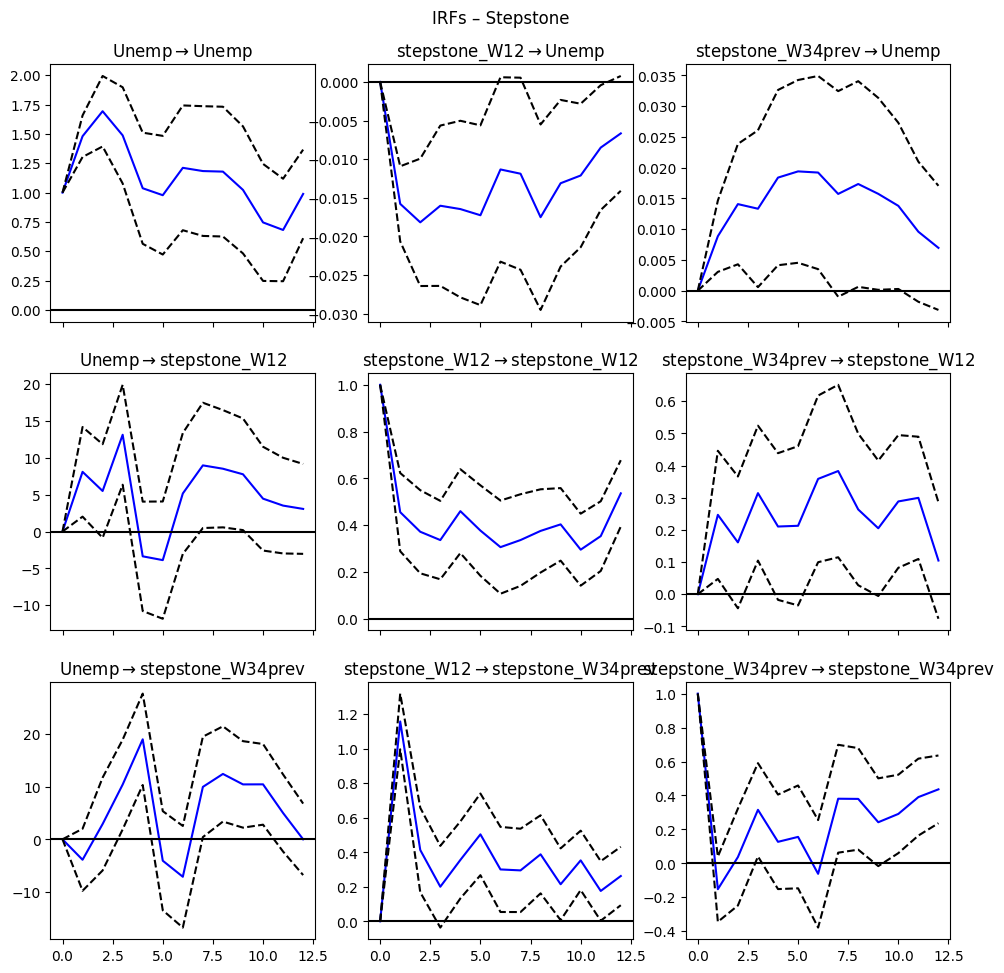

AttributeError: 'VECMResults' object has no attribute 'fevd'

In [ ]:
plot_irf(step["vecm"], 12, "IRFs – Stepstone")

Blue line: estimated response of the variable on the y-axis (row title).
Black dashed lines: 95 % confidence bands.
x-axis: horizon (in months, since your data are monthly).
y-axis: size of response (in original units).

| Panel                         | Interpretation                                                                                                                                                                                                                                            |
| ----------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Unemp → Unemp**             | Own shock — how unemployment persists after an unexpected rise in itself. You see a slowly decaying response → unemployment is persistent but mean-reverting.                                                                                             |
| **stepstone_W12 → Unemp**     | A positive shock in Stepstone W12 (new postings) slightly **reduces** unemployment in the first few months (blue line below zero). The effect fades after 4–6 months. That’s the intuitive labour-market signal: more postings → less unemployment later. |
| **stepstone_W34prev → Unemp** | A shock in W34prev (previous postings window) also **lowers** unemployment after a short delay, peaking around month 4–6 before fading. Again consistent with vacancies leading unemployment downward.                                                    |


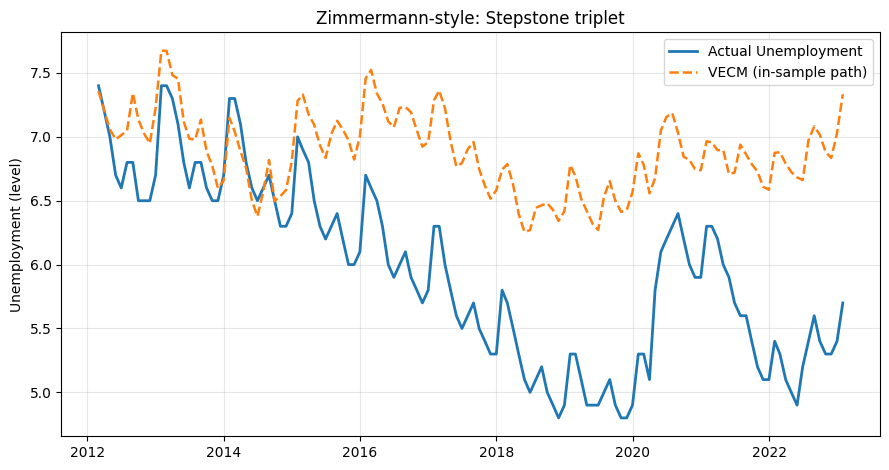

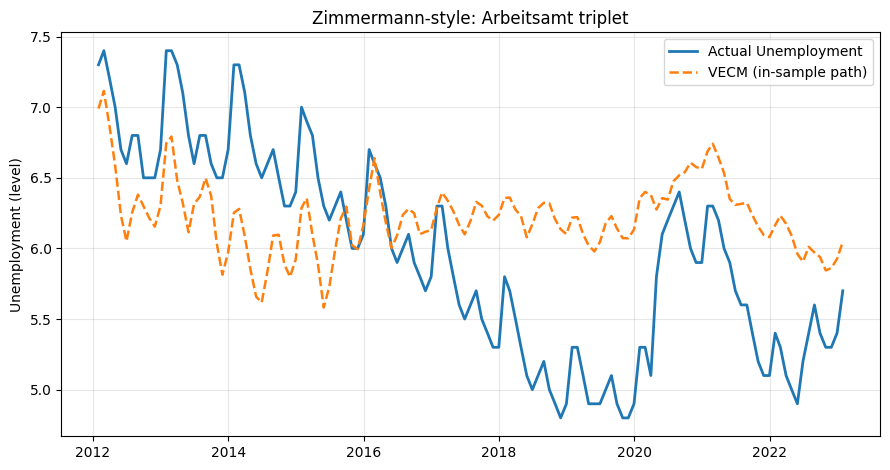

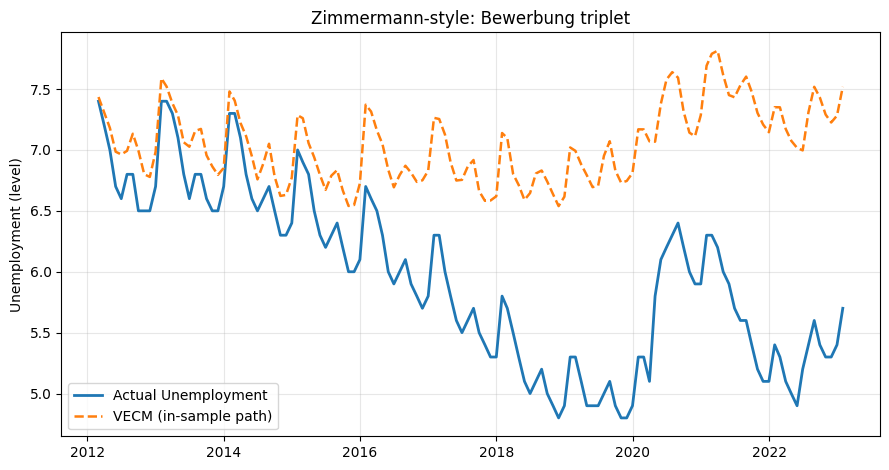

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def vecm_zimmermann_plot(model_dict, title="Zimmermann-style path"):
    """
    Rebuilds an in-sample Unemployment level path from a VECM by
    using fitted differences: dŶ = dY - ε, then cumulative sum + anchor.
    """
    vecm = model_dict["vecm"]       # VECMResults
    df   = model_dict["df"]         # levels DataFrame used to fit the VECM

    # Number of lagged diffs in the VECM (a.k.a. k_ar_diff)
    kdiff = int(vecm.model.k_ar_diff)

    # Residuals are available from t = kdiff+1 onward
    resid = pd.DataFrame(vecm.resid, columns=df.columns,
                         index=df.index[kdiff+1:])

    # Observed first differences aligned to residuals window
    dy = df.diff().loc[resid.index, "Unemp"]

    # Fitted differences: dŶ = dY - ε
    dy_hat = (dy - resid["Unemp"]).rename("dUnemp_hat")

    # Rebuild the level path: anchor = level at t-1 before first dŶ
    first_t = dy_hat.index[0]
    first_pos = df.index.get_loc(first_t)
    anchor_pos = first_pos - 1
    if anchor_pos < 0:
        raise ValueError("Need at least one level obs before the first fitted difference.")
    anchor_level = df["Unemp"].iloc[anchor_pos]

    path = (anchor_level + dy_hat.cumsum()).rename("Unemp_hat")

    # Align actual levels for plotting window
    actual = df["Unemp"].loc[path.index[0]:]

    plt.figure(figsize=(9,4.8))
    plt.plot(actual.index, actual.values, lw=2.0, label="Actual Unemployment")
    plt.plot(path.index,   path.values,   lw=1.8, ls="--", label="VECM (in-sample path)")
    plt.title(title)
    plt.ylabel("Unemployment (level)")
    plt.legend()
    plt.grid(alpha=.3)
    plt.tight_layout()
    plt.show()

vecm_zimmermann_plot(step, "Zimmermann-style: Stepstone triplet")
vecm_zimmermann_plot(arb,  "Zimmermann-style: Arbeitsamt triplet")
vecm_zimmermann_plot(bew,  "Zimmermann-style: Bewerbung triplet")


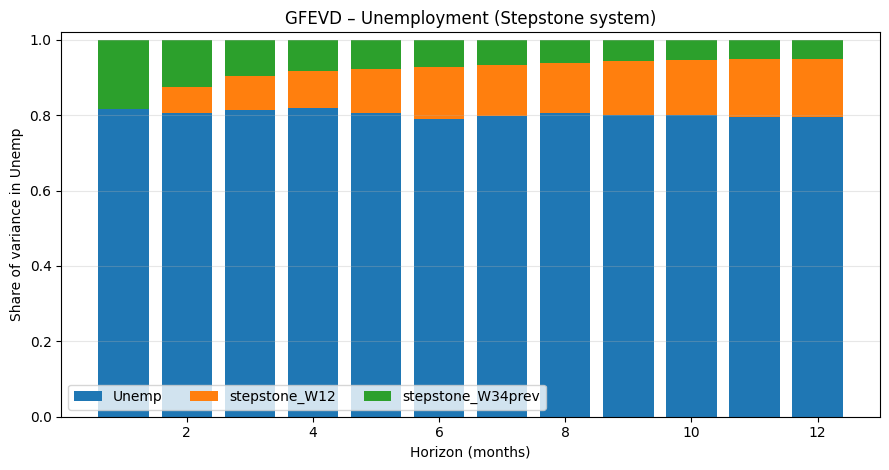

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def gfevd_from_vecm(model_dict, horizon=12):
    """
    Generalized FEVD (Pesaran & Shin, 1998) from a fitted VECMResults.
    Returns a DataFrame for each horizon with rows = affected variables,
    columns = shock variables. Entries sum to 1 across columns for each row.
    """
    vecm = model_dict["vecm"]            # VECMResults
    names = model_dict["df"].columns.tolist()
    n = len(names)

    # Non-orthogonal impulse responses Ψ_h (a.k.a. MA coefficients)
    ir = vecm.irf(horizon)               # IRAnalysisVECM
    # try common attribute names across statsmodels versions
    psi = getattr(ir, "irfs", None)
    if psi is None:
        psi = getattr(ir, "_irfs", None)
    if psi is None:
        raise AttributeError("Could not access non-orthogonal IRFs from VECM irf().")

    # psi shape is (H+1, n, n), with psi[0] ≈ I.
    # Σ = covariance of reduced-form errors
    Sigma = vecm.sigma_u                 # (n x n)
    Sigma_diag = np.diag(Sigma)          # σ_jj

    # containers
    tables = []
    for H in range(1, horizon+1):
        # cumulative numerator and denominator up to H
        num = np.zeros((n, n))
        den = np.zeros(n)

        for h in range(H):
            Ph = psi[h]                  # (n x n)
            # contribution matrix: C_h = Ph Σ
            C = Ph @ Sigma               # (n x n)
            # denominator part for each i: e_i' (Ph Σ Σ' Ph') e_i = row_i(C) @ row_i(Ph)
            # more directly: den_i += (e_i' Ph Σ Σ' Ph' e_i) = (C[h,i,:] @ Ph[i,:].T)
            # but we can use vectorized squares:
            # den_i += (e_i' Ph Σ Σ' Ph' e_i) = row_i( Ph @ Sigma @ Sigma.T @ Ph.T )*e_i
            # since Σ is symmetric, ΣΣ' = Σ^2 (matrix product)
            M = Ph @ Sigma @ Ph.T        # (n x n)
            den += np.diag(M)            # add diagonal → element-wise for i

            # numerator for each (i, j):
            # θ_ij(H) num += (e_i' Ph Σ e_j)^2 / σ_jj
            # which is C[i,j]^2 / σ_jj
            num += (C**2) / Sigma_diag

        # normalized FEVD rows so each row sums to 1
        # Avoid division by zero in degenerate cases
        den = np.where(den == 0, 1e-12, den)
        gfevd_H = (num.T / den).T        # row-wise divide
        # small numeric drift cleanup
        gfevd_H = np.clip(gfevd_H, 0, 1)
        rowsum = gfevd_H.sum(axis=1, keepdims=True)
        rowsum = np.where(rowsum == 0, 1, rowsum)
        gfevd_H = gfevd_H / rowsum

        df_H = pd.DataFrame(gfevd_H, index=names, columns=names)
        df_H.attrs["horizon"] = H
        tables.append(df_H)

    return tables  # list of DataFrames for horizons 1..H



def plot_gfevd_unemp(tables, title="GFEVD – Unemployment"):
    # collect the Unemp row across horizons
    horizons = [tbl.attrs.get("horizon", i+1) for i, tbl in enumerate(tables)]
    names = tables[0].columns.tolist()
    unemp_row = [tbl.loc["Unemp"].values for tbl in tables]  # list of (n,)
    A = np.vstack(unemp_row)                                  # (H x n)

    plt.figure(figsize=(9,4.8))
    bottom = np.zeros(len(horizons))
    for j, name in enumerate(names):
        plt.bar(horizons, A[:, j], bottom=bottom, label=name, width=0.8)
        bottom += A[:, j]
    plt.title(title)
    plt.xlabel("Horizon (months)")
    plt.ylabel("Share of variance in Unemp")
    plt.ylim(0, 1.02)
    plt.legend(ncol=min(3, len(names)))
    plt.grid(alpha=.3, axis="y")
    plt.tight_layout()
    plt.show()

# Example usage:
tables_step = gfevd_from_vecm(step, horizon=12)
plot_gfevd_unemp(tables_step, "GFEVD – Unemployment (Stepstone system)")

# tables_arb  = gfevd_from_vecm(arb,  horizon=12)
# plot_gfevd_unemp(tables_arb,  "GFEVD – Unemployment (Arbeitsamt system)")

# tables_bew  = gfevd_from_vecm(bew,  horizon=12)
# plot_gfevd_unemp(tables_bew,  "GFEVD – Unemployment (Bewerbung system)")



At horizon 1 (1 month ahead), about 80–85% of Unemployment forecast variance comes from its own innovations.
→ This is expected: short-run dynamics are dominated by persistence.

Around 3–6 months ahead, stepstone_W12 explains roughly 15–20% of the forecast error variance, while stepstone_W34prev adds another 5–10%.
→ That’s substantial — it means that up to ~¼ of the movements in Unemployment at short-to-medium horizons can be traced back to shocks in Stepstone indicators.

By 12 months ahead, the shares stabilize: Unemployment still accounts for ~80%, Stepstone variables ~20%.
→ The predictive influence persists, not just a temporary effect.

✅ Own-shock dominance (blue part):
Unemployment remains mostly explained by its own lagged structure — typical of labor market variables with strong persistence.

✅ Stepstone_W12 (orange):
This captures contemporaneous job search intensity or vacancies.
Its growing contribution suggests that web job market activity contains early signals about short-run unemployment movements.

✅ Stepstone_W34prev (green):
This lagged web measure likely reflects earlier application or posting behavior, hinting that labor market frictions and expectations feed into future unemployment trends with some delay.

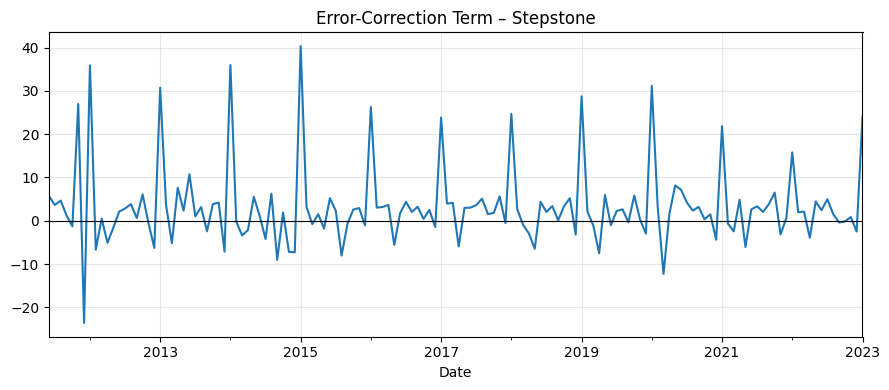

Stepstone | ADF stat=-3.025, p=0.0327 → stationary ✅


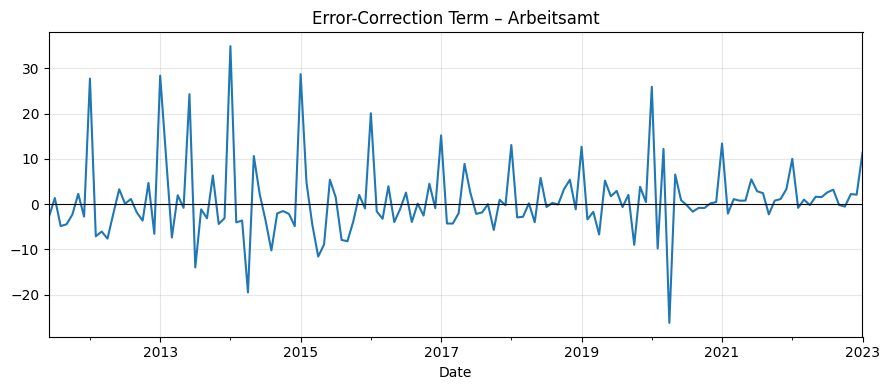

Arbeitsamt | ADF stat=-2.275, p=0.1800 → not clearly stationary ⚠️


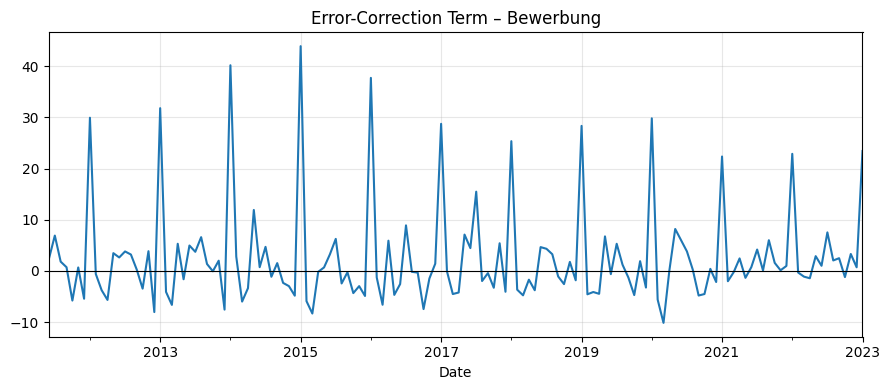

Bewerbung | ADF stat=-2.667, p=0.0798 → not clearly stationary ⚠️


In [40]:
from statsmodels.tsa.stattools import adfuller

def plot_ect(vecm_dict, name="System"):
    vecm = vecm_dict["vecm"]; df = vecm_dict["df"]
    # VECMResults often stores resid_coint; if not, compute β'y
    if getattr(vecm, "resid_coint", None) is not None:
        ect = pd.Series(np.asarray(vecm.resid_coint).squeeze(),
                        index=df.index[-len(vecm.resid_coint):], name="ECT")
    else:
        ect = pd.Series((df.values @ vecm.beta).squeeze(), index=df.index, name="ECT")

    plt.figure(figsize=(9,4))
    ect.plot(); plt.axhline(0,color="k",lw=.8); plt.grid(alpha=.3)
    plt.title(f"Error-Correction Term – {name}"); plt.tight_layout(); plt.show()

    adf = adfuller(ect.dropna(), autolag="AIC")
    print(f"{name} | ADF stat={adf[0]:.3f}, p={adf[1]:.4f} → "
          f"{'stationary ✅' if adf[1]<0.05 else 'not clearly stationary ⚠️'}")

# Example:
plot_ect(step, "Stepstone")
plot_ect(arb,  "Arbeitsamt")
plot_ect(bew,  "Bewerbung")


# Cointegration test for all for the case n

In [10]:
import pandas as pd
from statsmodels.tsa.stattools import coint

def engle_granger_case_n(panel, y_name='Unemp', maxlag=6, autolag='AIC'):
    results = []
    x_vars = [c for c in panel.columns if c != y_name]

    for x_name in x_vars:
        df = panel[[y_name, x_name]].dropna().astype(float)
        y, x = df[y_name], df[x_name]

        # Engle–Granger cointegration test (case n: no constant)
        eg_stat, eg_p, eg_crit = coint(y, x, trend='n', maxlag=maxlag, autolag=autolag)

        is_coint = (eg_p < 0.05) or (eg_stat < eg_crit[1])

        results.append({
            'Variable': x_name,
            'EG_stat': round(eg_stat, 3),
            'p_value': round(eg_p, 4),
            '5%_critical': round(eg_crit[1], 3),
            'Cointegrated?': 'Yes' if is_coint else 'No'
        })

    res_df = pd.DataFrame(results)
    print("\n--- Engle–Granger Cointegration Test (Case n: No Constant) ---")
    print(res_df.to_string(index=False))
    print("\nDecision rule: reject H₀ (no cointegration) if p < 0.05 or stat < 5% critical value.")
    return res_df

# Example call
# eg_results_n = engle_granger_case_n(panel, y_name='Unemp')


In [11]:
engle_granger_case_n(panel)


--- Engle–Granger Cointegration Test (Case n: No Constant) ---
          Variable  EG_stat  p_value  5%_critical Cointegrated?
     stepstone_W12   -3.391   0.0087          NaN           Yes
        indeed_W12   -1.902   0.2759          NaN            No
      jobbörse_W12   -0.177   0.9193          NaN            No
    arbeitsamt_W12   -1.246   0.5922          NaN            No
     bewerbung_W12   -1.207   0.6105          NaN            No
 stepstone_W34prev   -2.948   0.0310          NaN           Yes
    indeed_W34prev   -2.110   0.1966          NaN            No
  jobbörse_W34prev    0.372   0.9675          NaN            No
arbeitsamt_W34prev   -1.295   0.5689          NaN            No
 bewerbung_W34prev   -1.323   0.5554          NaN            No

Decision rule: reject H₀ (no cointegration) if p < 0.05 or stat < 5% critical value.


,Variable,EG_stat,p_value,5%_critical,Cointegrated?
0,stepstone_W12,-3.391,0.0087,NaN,Yes
1,indeed_W12,-1.902,0.2759,NaN,No
2,jobbörse_W12,-0.177,0.9193,NaN,No
3,arbeitsamt_W12,-1.246,0.5922,NaN,No
4,bewerbung_W12,-1.207,0.6105,NaN,No
5,stepstone_W34prev,-2.948,0.0310,NaN,Yes
6,indeed_W34prev,-2.110,0.1966,NaN,No
7,jobbörse_W34prev,0.372,0.9675,NaN,No
8,arbeitsamt_W34prev,-1.295,0.5689,NaN,No
9,bewerbung_W34prev,-1.323,0.5554,NaN,No


-> only cointegrated relationships for the cases
- stepstone_W12
- stepstone_W34prev

# Second case of engle granger test (with constant)

In [12]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

def engle_granger_case_c(panel, y_name='Unemp', maxlag=6, autolag='AIC'):
    results = []
    x_vars = [c for c in panel.columns if c != y_name]

    for x_name in x_vars:
        df = panel[[y_name, x_name]].dropna().astype(float)
        y, x = df[y_name], df[x_name]

        # --- OLS with constant (intercept) ---
        X = sm.add_constant(x)
        lr = sm.OLS(y, X).fit()

        # --- Engle–Granger cointegration test (case c: constant) ---
        eg_stat, eg_p, eg_crit = coint(y, x, trend='c', maxlag=maxlag, autolag=autolag)

        is_coint = (eg_p < 0.05) or (eg_stat < eg_crit[1])

        results.append({
            'Variable': x_name,
            'EG_stat': round(eg_stat, 3),
            'p_value': round(eg_p, 4),
            '5%_critical': round(eg_crit[1], 3),
            'Cointegrated?': 'Yes' if is_coint else 'No'
        })

    res_df = pd.DataFrame(results)
    print("\n--- Engle–Granger Cointegration Test (Case c: With Constant) ---")
    print(res_df.to_string(index=False))
    print("\nDecision rule: reject H₀ (no cointegration) if p < 0.05 or stat < 5% critical value.")
    return res_df

# Example call:
# eg_results_c = engle_granger_case_c(panel, y_name='Unemp')


In [13]:
engle_granger_case_c(panel)


--- Engle–Granger Cointegration Test (Case c: With Constant) ---
          Variable  EG_stat  p_value  5%_critical Cointegrated?
     stepstone_W12   -2.814   0.1614        -3.38            No
        indeed_W12   -2.846   0.1514        -3.38            No
      jobbörse_W12   -2.304   0.3714        -3.38            No
    arbeitsamt_W12   -3.107   0.0868        -3.38            No
     bewerbung_W12   -2.073   0.4903        -3.38            No
 stepstone_W34prev   -2.339   0.3541        -3.38            No
    indeed_W34prev   -2.427   0.3120        -3.38            No
  jobbörse_W34prev   -4.418   0.0017        -3.38           Yes
arbeitsamt_W34prev   -4.601   0.0008        -3.38           Yes
 bewerbung_W34prev   -1.868   0.5964        -3.38            No

Decision rule: reject H₀ (no cointegration) if p < 0.05 or stat < 5% critical value.


,Variable,EG_stat,p_value,5%_critical,Cointegrated?
0,stepstone_W12,-2.814,0.1614,-3.38,No
1,indeed_W12,-2.846,0.1514,-3.38,No
2,jobbörse_W12,-2.304,0.3714,-3.38,No
3,arbeitsamt_W12,-3.107,0.0868,-3.38,No
4,bewerbung_W12,-2.073,0.4903,-3.38,No
5,stepstone_W34prev,-2.339,0.3541,-3.38,No
6,indeed_W34prev,-2.427,0.3120,-3.38,No
7,jobbörse_W34prev,-4.418,0.0017,-3.38,Yes
8,arbeitsamt_W34prev,-4.601,0.0008,-3.38,Yes
9,bewerbung_W34prev,-1.868,0.5964,-3.38,No


-> only two cointegrated relationships
- one for jobbörse_W34 prev
- arebeitsamnt_W34 prev

# Take a closer look at the residuals from both cases

## First jobbörse prev

In [14]:
import statsmodels.api as sm
import pandas as pd

# y = dependent variable, x = independent
y = panel["Unemp"]
X = panel["jobbörse_W34prev"]

# add constant for intercept
X = sm.add_constant(X)

# estimate OLS
model = sm.OLS(y, X).fit()
print(model.summary())

# extract residuals (these are ε̂_t)
resid = model.resid


                            OLS Regression Results                            
Dep. Variable:                  Unemp   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     139.4
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           1.14e-22
Time:                        08:31:11   Log-Likelihood:                -103.15
No. Observations:                 140   AIC:                             210.3
Df Residuals:                     138   BIC:                             216.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                4.9261      0.101  

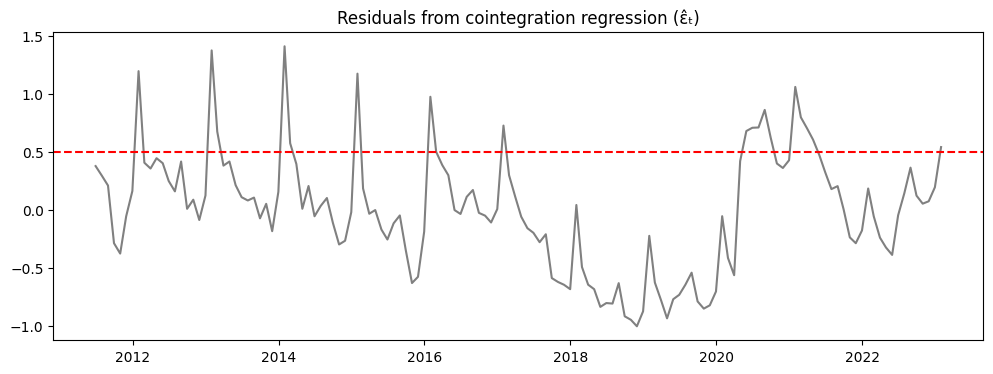

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(resid, color="gray")
plt.axhline(0.5, color="red", linestyle="--")
plt.title("Residuals from cointegration regression (ε̂ₜ)")
plt.show()


## Now for the arbeitsamt prev case

In [18]:
import statsmodels.api as sm
import pandas as pd

# y = dependent variable, x = independent
y = panel["Unemp"]
X = panel["arbeitsamt_W34prev"]

# add constant for intercept
X = sm.add_constant(X)

# estimate OLS
model = sm.OLS(y, X).fit()
print(model.summary())

# extract residuals (these are ε̂_t)
resid = model.resid


                            OLS Regression Results                            
Dep. Variable:                  Unemp   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     116.5
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           4.56e-20
Time:                        08:32:57   Log-Likelihood:                -109.18
No. Observations:                 140   AIC:                             222.4
Df Residuals:                     138   BIC:                             228.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  4.6563      0

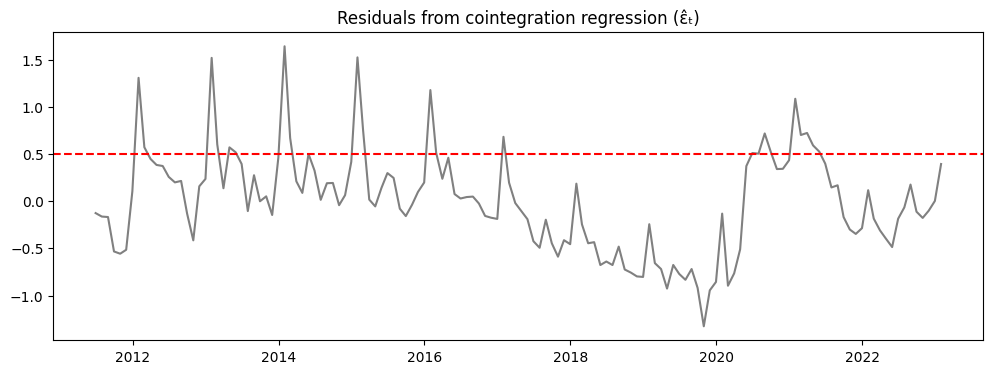

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(resid, color="gray")
plt.axhline(0.5, color="red", linestyle="--")
plt.title("Residuals from cointegration regression (ε̂ₜ)")
plt.show()


# ECM for the different cases

## ECM for just jobbörse

In [30]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

df = panel.copy()

# --- 1) Create differences and lags
df["dUnemp"] = df["Unemp"].diff()
df["dUnemp_lag"] = df["dUnemp"].shift(1)

df["dj34"] = df["jobbörse_W34prev"].diff()
df["dj34_lag"] = df["dj34"].shift(1)

#df["dA12"] = df["stepstone_W12"].diff()
#df["dA12_lag"] = df["dA12"].shift(1)

df["month"] = df.index.month

# --- 2) LONG-RUN COINTEGRATION (CASE 'c' = with constant)
# Add intercepts in the cointegrating regressions
lr_c_early = smf.ols("Unemp ~ jobbörse_W34prev", data=df).fit()
df["EC_early_lag"] = lr_c_early.resid.shift(1)

#lr_c_late = smf.ols("Unemp ~ stepstone_W34prev + stepstone_W12", data=df).fit()
#df["EC_late_lag"] = lr_c_late.resid.shift(1)

# --- 3) Drop missing rows created by lags/diffs
used_cols = [
    "dUnemp", "dUnemp_lag", "dj34", "dj34_lag",
    "EC_early_lag", "month"
]
used = df.dropna(subset=used_cols)

# --- 4) SHORT-RUN ECMs (with constant + monthly dummies)
# Intercept is included automatically by smf.ols

mod_early = smf.ols(
    "dUnemp ~ EC_early_lag + dUnemp_lag + dj34 + dj34_lag + C(month)",
    data=used
).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

#mod_late = smf.ols(
#    "dUnemp ~ EC_late_lag + dUnemp_lag + dA34 + dA34_lag + dA12 + dA12_lag + C(month)",
#    data=used
#).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

# --- 5) Print results
print("\n=== ECM (Early: A34 only, Case 'c' long run) ===")
print(lr_c_early.summary())
print(mod_early.summary())

#print("\n=== ECM (Late: A34 + A12, Case 'c' long run) ===")
#print(lr_c_late.summary())
#print(mod_late.summary())



=== ECM (Early: A34 only, Case 'c' long run) ===
                            OLS Regression Results                            
Dep. Variable:                  Unemp   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     139.4
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           1.14e-22
Time:                        09:03:44   Log-Likelihood:                -103.15
No. Observations:                 140   AIC:                             210.3
Df Residuals:                     138   BIC:                             216.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

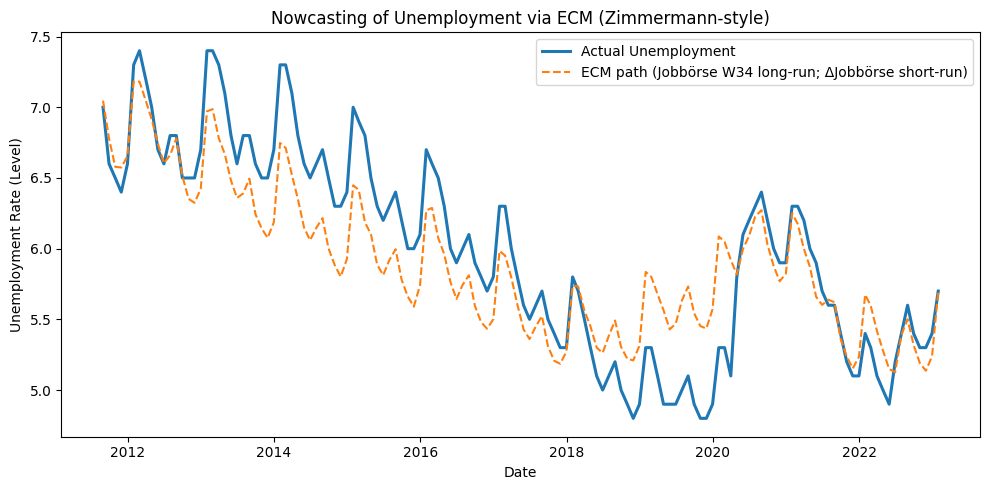

Speed of adjustment φ (EC_early_lag): -0.0398
In-sample RMSE (levels, aligned): 0.3512


In [33]:
# --- Reconstruct levels from predicted differences and plot (Zimmermann-style) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) In-sample predictions of ΔUnemp from your fitted model
pred_d = pd.Series(mod_early.predict(used), index=used.index, name="dUnemp_hat")

# 2) Helper to rebuild levels from predicted differences
def rebuild_level(level_series: pd.Series, d_hat: pd.Series) -> pd.Series:
    """
    Rebuild a level path from predicted differences (Δy).
    Anchor at the observed level at t-1 (one period before the first prediction),
    then cumulatively sum the predicted differences.
    """
    first_t = d_hat.index.min()
    # Find anchor position (t-1) in the level index
    # (assumes same DateTimeIndex frequency; if not exact match, align to closest)
    if first_t not in level_series.index:
        # align to nearest index on/after first_t
        first_t = level_series.index[level_series.index.get_indexer([first_t], method="nearest")[0]]
    anchor_pos = level_series.index.get_loc(first_t) - 1
    if anchor_pos < 0:
        raise ValueError("Need at least one observed level before the first predicted difference.")

    anchor_level = level_series.iloc[anchor_pos]
    path = (anchor_level + d_hat.cumsum()).rename("ECM_level_path")
    return path

# 3) Build ECM-implied level path
ecm_path = rebuild_level(df["Unemp"], pred_d)

# 4) Align actual levels to plotting window
plot_start = ecm_path.index.min()
actual = df["Unemp"].loc[plot_start:]
ecm_path = ecm_path.loc[plot_start:]

# 5) Simple fit metric (levels)
rmse = float(np.sqrt(np.mean((actual.loc[ecm_path.index] - ecm_path)**2)))

# 6) Plot
plt.figure(figsize=(10,5))
plt.plot(actual.index, actual.values, label="Actual Unemployment", linewidth=2.2)
plt.plot(ecm_path.index, ecm_path.values, linestyle="--",
         label="ECM path (Jobbörse W34 long-run; ΔJobbörse short-run)")
plt.title("Nowcasting of Unemployment via ECM (Zimmermann-style)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (Level)")
plt.legend()
plt.tight_layout()
plt.show()

# 7) Report speed of adjustment and RMSE
phi = mod_early.params.get("EC_early_lag", np.nan)
print("Speed of adjustment φ (EC_early_lag):", round(phi, 4))
print("In-sample RMSE (levels, aligned):", round(rmse, 4))


## Jobbörse and then add Arbeitsamt

In [28]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# --- 0) Copy and sanitize column names for formulas (ASCII-friendly)
df = panel.copy()

# Make a safe alias for Jobbörse
if "jobbörse_W34prev" in df.columns:
    df = df.rename(columns={"jobbörse_W34prev": "jobboerse_W34prev"})

# --- 1) Create differences and lags (monthly)
df["dUnemp"] = df["Unemp"].astype(float).diff()
df["dUnemp_lag"] = df["dUnemp"].shift(1)

df["dJ34"] = df["jobboerse_W34prev"].astype(float).diff()
df["dJ34_lag"] = df["dJ34"].shift(1)

df["dA34"] = df["arbeitsamt_W34prev"].astype(float).diff()
df["dA34_lag"] = df["dA34"].shift(1)

df["month"] = df.index.month

# --- 2) LONG-RUN COINTEGRATION (CASE 'c' = with constant)
# Unemp_t = alpha + beta * Jobboerse34_t + u_t
lr_c = smf.ols("Unemp ~ jobboerse_W34prev", data=df).fit()
df["EC_lag"] = lr_c.resid.shift(1)   # error-correction term lagged one period

# --- 3) Build ECM dataset (drop NA from diffs/lags)
used_cols = ["dUnemp","dUnemp_lag","dJ34","dJ34_lag","dA34","dA34_lag","EC_lag","month"]
ecm_data = df.dropna(subset=used_cols).copy()

# --- 4) SHORT-RUN ECM (with constant + monthly dummies)
# ΔUnemp_t = φ*EC_{t-1} + γ1*ΔJobboerse34_t + γ2*ΔJobboerse34_{t-1}
#          + δ1*ΔArbeitsamt34_t + δ2*ΔArbeitsamt34_{t-1}
#          + ρ*ΔUnemp_{t-1} + monthly dummies + ε_t
mod = smf.ols(
    "dUnemp ~ EC_lag + dUnemp_lag + dJ34 + dJ34_lag + dA34 + dA34_lag + C(month)",
    data=ecm_data
).fit(cov_type="HAC", cov_kwds={"maxlags": 12})  # monthly → HAC(12) is standard

print("\n=== Long-run (case c) ===")
print(lr_c.summary())

print("\n=== ECM (Jobbörse long-run; Arbeitsamt in short-run) ===")
print(mod.summary())



=== Long-run (case c) ===
                            OLS Regression Results                            
Dep. Variable:                  Unemp   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     139.4
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           1.14e-22
Time:                        09:03:14   Log-Likelihood:                -103.15
No. Observations:                 140   AIC:                             210.3
Df Residuals:                     138   BIC:                             216.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept  

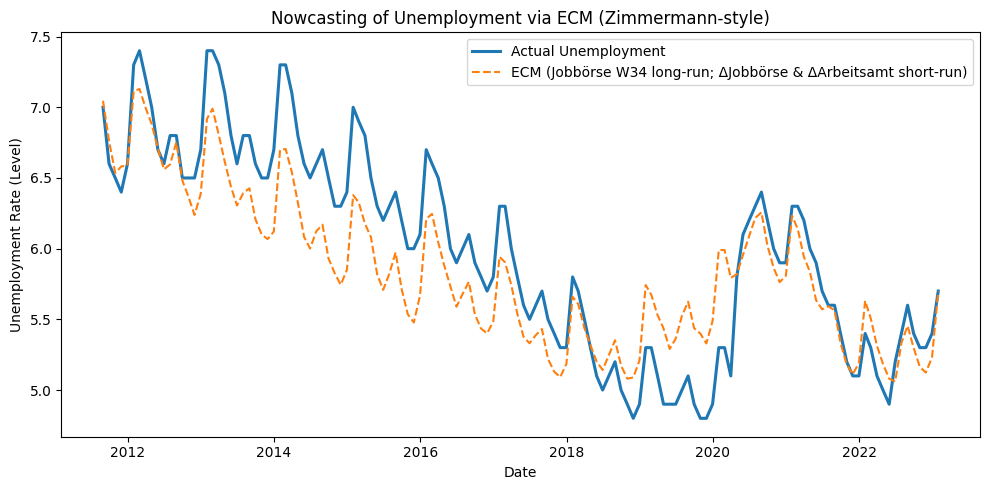

Speed of adjustment φ (EC_lag): -0.0384
In-sample RMSE (levels, aligned): 0.352


In [29]:
# --- Plotting + path reconstruction for the single ECM you built ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumptions from your previous step:
# - 'df' is your full dataframe with 'Unemp' as a column and DateTimeIndex
# - 'ecm_data' is the dataframe used to fit the ECM (after dropna)
# - 'mod' is the fitted ECM: smf.ols(...).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

# 1) In-sample predicted differences
pred_d = pd.Series(mod.predict(ecm_data), index=ecm_data.index, name="dUnemp_hat")

# 2) Helper: rebuild level path from predicted differences
def rebuild_level(level_series: pd.Series, d_hat: pd.Series) -> pd.Series:
    """
    Rebuild a level path from predicted differences (Δy).
    Anchor at the observed level at t-1 (one period before the first prediction),
    then cumulatively sum the predicted differences.
    """
    first_t = d_hat.index.min()
    # Find anchor position (t-1) in the level index
    try:
        anchor_pos = level_series.index.get_loc(first_t) - 1
    except KeyError:
        # If indices are not exactly matching, align to nearest index on or after first_t
        first_t = level_series.index[level_series.index.get_indexer([first_t], method="nearest")[0]]
        anchor_pos = level_series.index.get_loc(first_t) - 1

    if anchor_pos < 0:
        raise ValueError("Need at least one observed level before the first predicted difference.")
    anchor_level = level_series.iloc[anchor_pos]

    path = (anchor_level + d_hat.cumsum()).rename("ECM_level_path")
    return path

# 3) Build ECM-implied level path
ecm_path = rebuild_level(df["Unemp"], pred_d)

# 4) Align actual levels to the plotting window
plot_start = ecm_path.index.min()
actual = df["Unemp"].loc[plot_start:]
ecm_path = ecm_path.loc[plot_start:]

# 5) (Optional) summary fit metric on aligned window
rmse = np.sqrt(np.mean((actual.loc[ecm_path.index] - ecm_path)**2))

# 6) Plot (Zimmermann-style)
plt.figure(figsize=(10,5))
plt.plot(actual.index, actual.values, label="Actual Unemployment", linewidth=2.2)
plt.plot(ecm_path.index, ecm_path.values, linestyle="--",
         label="ECM (Jobbörse W34 long-run; ΔJobbörse & ΔArbeitsamt short-run)")
plt.title("Nowcasting of Unemployment via ECM (Zimmermann-style)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (Level)")
plt.legend()
plt.tight_layout()
plt.show()

# 7) Print key ECM coefficient (speed of adjustment φ) and RMSE
phi = mod.params.get("EC_lag", np.nan)
print("Speed of adjustment φ (EC_lag):", round(phi, 4))
print("In-sample RMSE (levels, aligned):", round(rmse, 4))


## For arebeitsamt 34

In [35]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

df = panel.copy()

# --- 1) Create differences and lags
df["dUnemp"] = df["Unemp"].diff()
df["dUnemp_lag"] = df["dUnemp"].shift(1)

df["da34"] = df["arbeitsamt_W34prev"].diff()
df["da34_lag"] = df["da34"].shift(1)

#df["dA12"] = df["stepstone_W12"].diff()
#df["dA12_lag"] = df["dA12"].shift(1)

df["month"] = df.index.month

# --- 2) LONG-RUN COINTEGRATION (CASE 'c' = with constant)
# Add intercepts in the cointegrating regressions
lr_c_early = smf.ols("Unemp ~ arbeitsamt_W34prev", data=df).fit()
df["EC_early_lag"] = lr_c_early.resid.shift(1)

#lr_c_late = smf.ols("Unemp ~ stepstone_W34prev + stepstone_W12", data=df).fit()
#df["EC_late_lag"] = lr_c_late.resid.shift(1)

# --- 3) Drop missing rows created by lags/diffs
used_cols = [
    "dUnemp", "dUnemp_lag", "da34", "da34_lag",
    "EC_early_lag", "month"
]
used = df.dropna(subset=used_cols)

# --- 4) SHORT-RUN ECMs (with constant + monthly dummies)
# Intercept is included automatically by smf.ols

mod_early = smf.ols(
    "dUnemp ~ EC_early_lag + dUnemp_lag + da34 + da34_lag + C(month)",
    data=used
).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

#mod_late = smf.ols(
#    "dUnemp ~ EC_late_lag + dUnemp_lag + dA34 + dA34_lag + dA12 + dA12_lag + C(month)",
#    data=used
#).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

# --- 5) Print results
print("\n=== ECM (Early: A34 only, Case 'c' long run) ===")
print(lr_c_early.summary())
print(mod_early.summary())

#print("\n=== ECM (Late: A34 + A12, Case 'c' long run) ===")
#print(lr_c_late.summary())
#print(mod_late.summary())



=== ECM (Early: A34 only, Case 'c' long run) ===
                            OLS Regression Results                            
Dep. Variable:                  Unemp   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     116.5
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           4.56e-20
Time:                        09:06:02   Log-Likelihood:                -109.18
No. Observations:                 140   AIC:                             222.4
Df Residuals:                     138   BIC:                             228.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

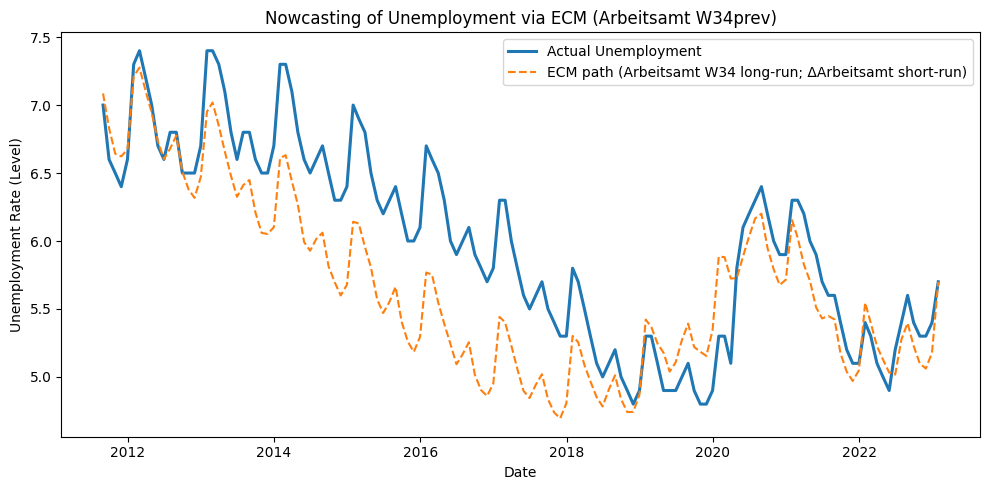

Speed of adjustment φ (EC_early_lag): -0.0587
In-sample RMSE (levels, aligned): 0.4948


In [36]:
# --- Reconstruct levels from predicted differences and plot (Arbeitsamt ECM) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) In-sample predictions of ΔUnemp from your fitted model
pred_d = pd.Series(mod_early.predict(used), index=used.index, name="dUnemp_hat")

# 2) Helper to rebuild levels from predicted differences
def rebuild_level(level_series: pd.Series, d_hat: pd.Series) -> pd.Series:
    """
    Rebuild a level path from predicted differences (Δy).
    Anchor at the observed level at t-1 (one period before the first prediction),
    then cumulatively sum the predicted differences.
    """
    first_t = d_hat.index.min()
    if first_t not in level_series.index:
        # align to nearest index on/after first_t
        first_t = level_series.index[level_series.index.get_indexer([first_t], method="nearest")[0]]
    anchor_pos = level_series.index.get_loc(first_t) - 1
    if anchor_pos < 0:
        raise ValueError("Need at least one observed level before the first predicted difference.")
    anchor_level = level_series.iloc[anchor_pos]
    return (anchor_level + d_hat.cumsum()).rename("ECM_level_path")

# 3) Build ECM-implied level path
ecm_path = rebuild_level(df["Unemp"], pred_d)

# 4) Align actual levels to plotting window
plot_start = ecm_path.index.min()
actual = df["Unemp"].loc[plot_start:]
ecm_path = ecm_path.loc[plot_start:]

# 5) Fit metric (levels)
rmse = float(np.sqrt(np.mean((actual.loc[ecm_path.index] - ecm_path)**2)))

# 6) Plot
plt.figure(figsize=(10,5))
plt.plot(actual.index, actual.values, label="Actual Unemployment", linewidth=2.2)
plt.plot(ecm_path.index, ecm_path.values, linestyle="--",
         label="ECM path (Arbeitsamt W34 long-run; ΔArbeitsamt short-run)")
plt.title("Nowcasting of Unemployment via ECM (Arbeitsamt W34prev)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (Level)")
plt.legend()
plt.tight_layout()
plt.show()

# 7) Report speed of adjustment and RMSE
phi = mod_early.params.get("EC_early_lag", np.nan)
print("Speed of adjustment φ (EC_early_lag):", round(phi, 4))
print("In-sample RMSE (levels, aligned):", round(rmse, 4))


## arebeitsamt with jobbörse

In [26]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# --- 0) Copy and sanitize column names for formulas (ASCII-friendly)
df = panel.copy()

# Make a safe alias for Jobbörse
if "jobbörse_W34prev" in df.columns:
    df = df.rename(columns={"jobbörse_W34prev": "jobboerse_W34prev"})

# --- 1) Create differences and lags (monthly)
df["dUnemp"] = df["Unemp"].astype(float).diff()
df["dUnemp_lag"] = df["dUnemp"].shift(1)

df["dJ34"] = df["jobboerse_W34prev"].astype(float).diff()
df["dJ34_lag"] = df["dJ34"].shift(1)

df["dA34"] = df["arbeitsamt_W34prev"].astype(float).diff()
df["dA34_lag"] = df["dA34"].shift(1)

df["month"] = df.index.month

# --- 2) LONG-RUN COINTEGRATION (CASE 'c' = with constant)
# Unemp_t = alpha + beta * Jobboerse34_t + u_t
lr_c = smf.ols("Unemp ~ arbeitsamt_W34prev", data=df).fit()
df["EC_lag"] = lr_c.resid.shift(1)   # error-correction term lagged one period

# --- 3) Build ECM dataset (drop NA from diffs/lags)
used_cols = ["dUnemp","dUnemp_lag","dJ34","dJ34_lag","dA34","dA34_lag","EC_lag","month"]
ecm_data = df.dropna(subset=used_cols).copy()

# --- 4) SHORT-RUN ECM (with constant + monthly dummies)
# ΔUnemp_t = φ*EC_{t-1} + γ1*ΔJobboerse34_t + γ2*ΔJobboerse34_{t-1}
#          + δ1*ΔArbeitsamt34_t + δ2*ΔArbeitsamt34_{t-1}
#          + ρ*ΔUnemp_{t-1} + monthly dummies + ε_t
mod = smf.ols(
    "dUnemp ~ EC_lag + dUnemp_lag + dJ34 + dJ34_lag + dA34 + dA34_lag + C(month)",
    data=ecm_data
).fit(cov_type="HAC", cov_kwds={"maxlags": 12})  # monthly → HAC(12) is standard

print("\n=== Long-run (case c) ===")
print(lr_c.summary())

print("\n=== ECM (Jobbörse long-run; Arbeitsamt in short-run) ===")
print(mod.summary())



=== Long-run (case c) ===
                            OLS Regression Results                            
Dep. Variable:                  Unemp   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     116.5
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           4.56e-20
Time:                        09:00:17   Log-Likelihood:                -109.18
No. Observations:                 140   AIC:                             222.4
Df Residuals:                     138   BIC:                             228.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept

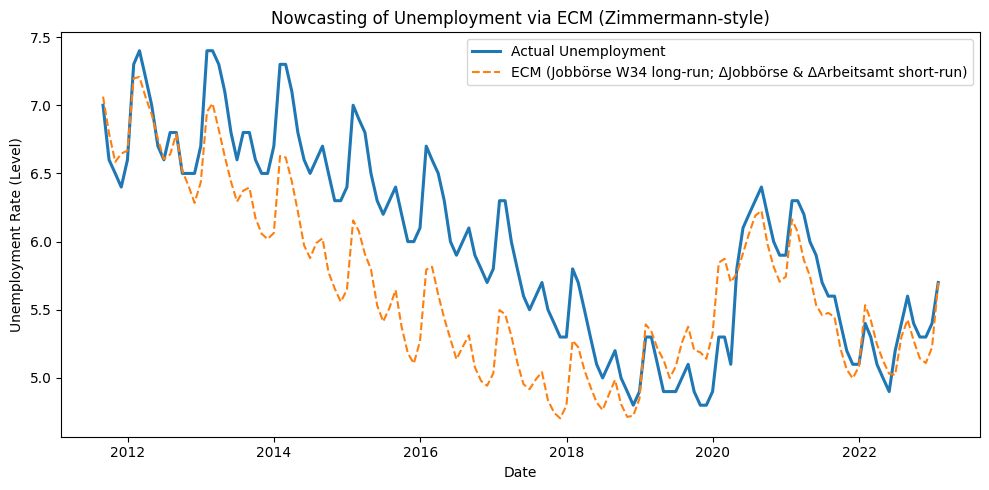

Speed of adjustment φ (EC_lag): -0.0553
In-sample RMSE (levels, aligned): 0.4897


In [27]:
# --- Plotting + path reconstruction for the single ECM you built ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumptions from your previous step:
# - 'df' is your full dataframe with 'Unemp' as a column and DateTimeIndex
# - 'ecm_data' is the dataframe used to fit the ECM (after dropna)
# - 'mod' is the fitted ECM: smf.ols(...).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

# 1) In-sample predicted differences
pred_d = pd.Series(mod.predict(ecm_data), index=ecm_data.index, name="dUnemp_hat")

# 2) Helper: rebuild level path from predicted differences
def rebuild_level(level_series: pd.Series, d_hat: pd.Series) -> pd.Series:
    """
    Rebuild a level path from predicted differences (Δy).
    Anchor at the observed level at t-1 (one period before the first prediction),
    then cumulatively sum the predicted differences.
    """
    first_t = d_hat.index.min()
    # Find anchor position (t-1) in the level index
    try:
        anchor_pos = level_series.index.get_loc(first_t) - 1
    except KeyError:
        # If indices are not exactly matching, align to nearest index on or after first_t
        first_t = level_series.index[level_series.index.get_indexer([first_t], method="nearest")[0]]
        anchor_pos = level_series.index.get_loc(first_t) - 1

    if anchor_pos < 0:
        raise ValueError("Need at least one observed level before the first predicted difference.")
    anchor_level = level_series.iloc[anchor_pos]

    path = (anchor_level + d_hat.cumsum()).rename("ECM_level_path")
    return path

# 3) Build ECM-implied level path
ecm_path = rebuild_level(df["Unemp"], pred_d)

# 4) Align actual levels to the plotting window
plot_start = ecm_path.index.min()
actual = df["Unemp"].loc[plot_start:]
ecm_path = ecm_path.loc[plot_start:]

# 5) (Optional) summary fit metric on aligned window
rmse = np.sqrt(np.mean((actual.loc[ecm_path.index] - ecm_path)**2))

# 6) Plot (Zimmermann-style)
plt.figure(figsize=(10,5))
plt.plot(actual.index, actual.values, label="Actual Unemployment", linewidth=2.2)
plt.plot(ecm_path.index, ecm_path.values, linestyle="--",
         label="ECM (Jobbörse W34 long-run; ΔJobbörse & ΔArbeitsamt short-run)")
plt.title("Nowcasting of Unemployment via ECM (Zimmermann-style)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (Level)")
plt.legend()
plt.tight_layout()
plt.show()

# 7) Print key ECM coefficient (speed of adjustment φ) and RMSE
phi = mod.params.get("EC_lag", np.nan)
print("Speed of adjustment φ (EC_lag):", round(phi, 4))
print("In-sample RMSE (levels, aligned):", round(rmse, 4))


# Johansen rank test

In [37]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
import numpy as np, pandas as pd

# pick the I(1) set you want in the system
vec = panel[['Unemp','arbeitsamt_W34prev','jobbörse_W34prev']].dropna().astype(float)

# 1) Johansen rank selection (deterministics='ci' adds constant in cointegration)
jres = coint_johansen(vec, det_order=1, k_ar_diff=2)  # try k_ar_diff via AIC grid search
print("trace stats:", jres.lr1, "\ncrit (95%):", jres.cvt[:,1])
rank = sum(jres.lr1 > jres.cvt[:,1])  # number of coint relations

# 2) Fit VECM with that rank
vecm = VECM(vec, k_ar_diff=2, coint_rank=rank, deterministic='co').fit()  # constant restricted to short-run
print(vecm.summary())


trace stats: [67.36116326 21.0583355   8.38089033] 
crit (95%): [35.0116 18.3985  3.8415]
   Det. terms outside the coint. relation & lagged endog. parameters for equation Unemp  
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.5092      0.186      2.744      0.006       0.146       0.873
L1.Unemp                  0.4693      0.096      4.895      0.000       0.281       0.657
L1.arbeitsamt_W34prev    -0.0065      0.003     -2.095      0.036      -0.013      -0.000
L1.jobbörse_W34prev       0.0050      0.003      1.571      0.116      -0.001       0.011
L2.Unemp                 -0.2790      0.106     -2.621      0.009      -0.488      -0.070
L2.arbeitsamt_W34prev    -0.0064      0.003     -2.254      0.024      -0.012      -0.001
L2.jobbörse_W34prev       0.0010      0.003      0.403      0.687      -0.004       0.006
Det. terms

Estimates common trend(s) across Unemp + Google indicators.
Gives speed-of-adjustment for Unemp (and for the Google series).
Enables system IRFs and FEVDs (see §4 visuals).

This test generalizes the idea of Engle Granger to more than two variables. It shows : how many linearly independent long-run equilibrium relationships (cointegrating vectors) exist among the set of variables.
If I have three variables, I can have up to max 2 cointegrating relationships, since the max rank is n-1.

Our result is somehow that we reject at 95 % all three HO. Usually it suggests the model may have too many lags or an overfitted deterministic trend.
So in practice with 3 variables we have rank 2 : There are two statistically significant long-run equilibrium relationships among unemployment, Arbeitsamt, and Jobbörse.

→ Only ec1 is significant and negative (−0.1137). The first long-run relationship significantly influences unemployment dynamics.
When the system deviates from this equilibrium, unemployment corrects about 11% per month toward it.

**The loadings for other variables**:

- Arbeitsamt: ec1 and ec2 significant → means both long-run equilibria affect Arbeitsamt dynamics.
- Jobbörse: ec1 significant, others not → primarily co-moves with the same long-run relation as Unemp.
So, ec1 looks like your “main economic cointegrating relation” between Unemployment and the two Google series

In [42]:
vecm.beta  # matrix of cointegrating vectors
pd.DataFrame(vecm.beta, index=vec.columns)


,0,1,2
Unemp,1.000000e+00,1.672024e-16,8.870944e-18
arbeitsamt_W34prev,-1.551044e-17,1.000000e+00,2.167011e-16
jobbörse_W34prev,5.225463e-17,1.638332e-16,1.000000e+00


<Axes: xlabel='Date'>

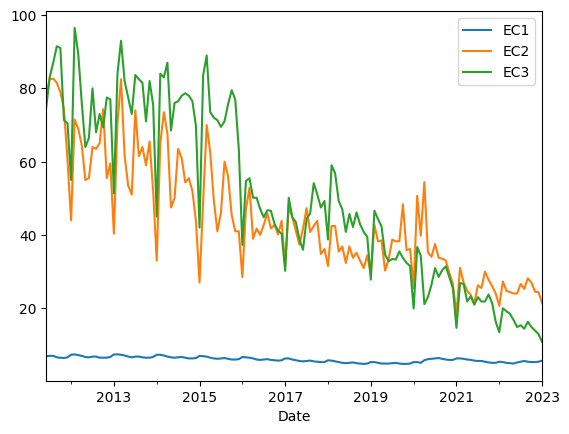

In [39]:
ec_terms = vecm.beta.T @ vec.values.T
pd.DataFrame(ec_terms.T, index=vec.index, columns=[f"EC{i+1}" for i in range(rank)]).plot()


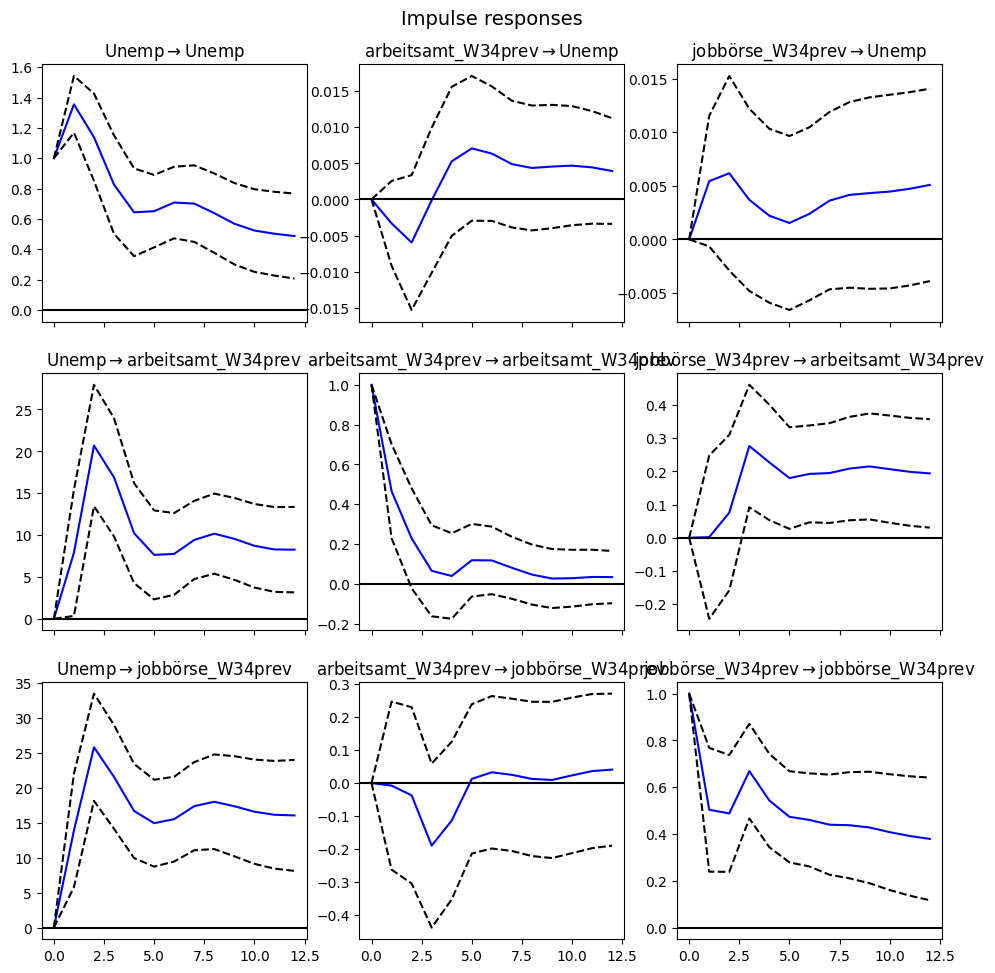

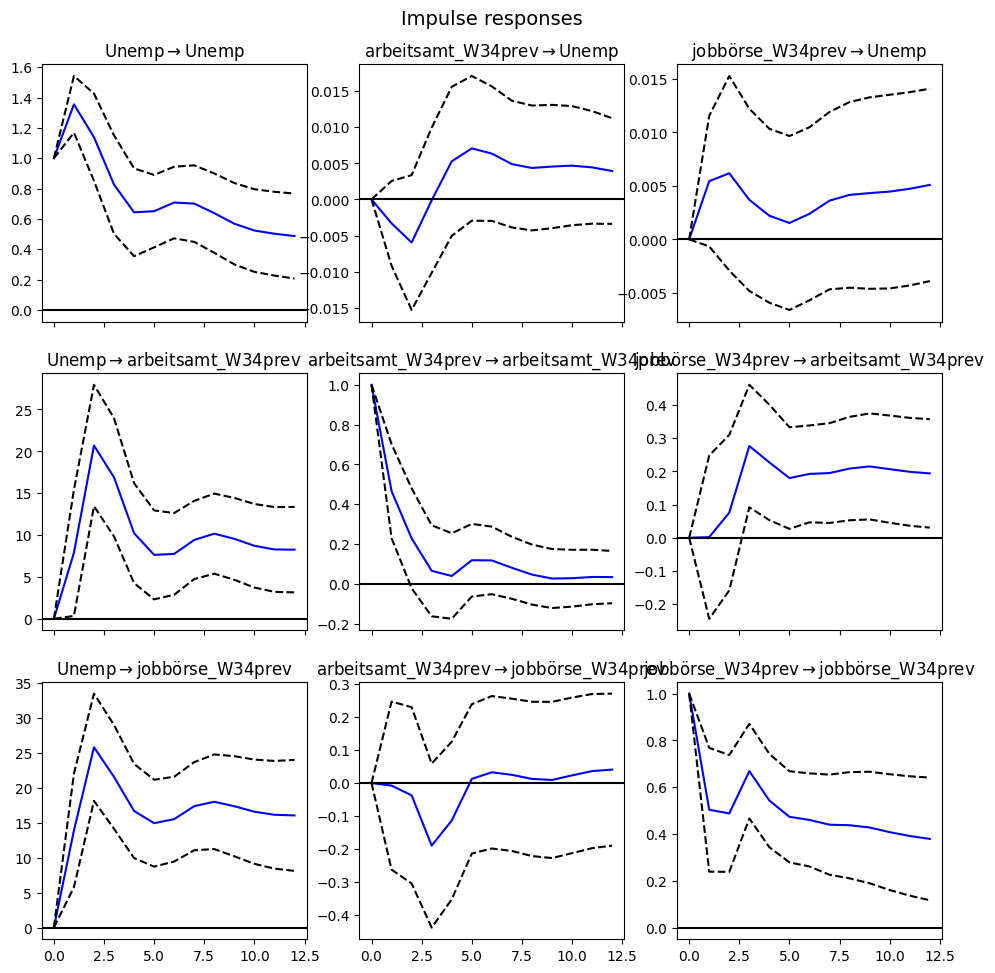

In [40]:
irf = vecm.irf(12)
irf.plot(orth=False)


# For the non cointegrated variables -> VAR in first differences

In [38]:
from statsmodels.tsa.api import VAR
X = panel[['dUnemp','d_someNonCointVar']].dropna()
model = VAR(X)
sel = model.select_order(maxlags=12)
var = model.fit(sel.aic)
print(var.summary())

# IRF
irf = var.irf(12)
irf.plot(orth=False);  # ΔUnemp response to Δx shock


KeyError: "None of [Index(['dUnemp', 'd_someNonCointVar'], dtype='object')] are in the [columns]"